# INP浓度和降水量的时间序列 (2025.01)

可以改动的东西有: 温度(即选择不同温度下的INP浓度)和日期

## -15degC

In [ ]:
## 导入相关库, 定义函数(用于数据处理)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

def extract_segment_last(s):
    """
    输入: 一个 Series 对象, 这个 Series 由'数据--NaN--数据'交替组成.

    返回: Series 对象, 包含每个测量段的最后一个值(认为数据趋于稳定后才有意义), 索引为这些值的原始索引.

    调用此函数前, 需要:
    - import numpy as np
    - import pandas as pd
    """
    ### 保证输入是 Series
    if not isinstance(s, pd.Series):
        raise TypeError("Input must be a pandas Series.")
    
    ### 1. 提取每段非 NaN 区间的尾值
    mask = s.notna() & s.shift(-1).isna()
    s_last = s[mask]

    ### 2. 如果没有尾值，返回空 Series
    if len(s_last) == 0:
        return pd.Series(dtype=float)
    
    return s_last


def compute_net(sam, bac):
    """
    输入: 两个 Series 对象(索引为整数), 计算净值 (Sample - Background), 如果净值小于 0, 则取 0.

    返回: Series 对象, 索引为两个输入 Series 索引的平均值.

    调用此函数前, 需要:
    - import numpy as np
    - import pandas as pd
    - 定义 extract_segment_last 函数, 用于获取每个测量段的最后一个值
    """

    sam = extract_segment_last(sam)
    bac = extract_segment_last(bac)

    ### 保证两个 Series 长度相同
    if len(sam) != len(bac):
        print("Sample and background have different number of measurement segments.")
        
        ### 如果长度不一致, 尝试进行处理: 
        df1 = pd.DataFrame({'value': sam, 'tag': 'Sample'})
        df2 = pd.DataFrame({'value': bac, 'tag': 'Background'})
        df = pd.concat([df1, df2]).sort_index()
        #### 调试输出, 用于验证删除是否正确
        print("Before processing:")
        print(df)
        #### 删除连续两段数据的前一段 (即, 若连续两段数据属于同一tag, 保留后一段)
        df = df.drop(df[df['tag'] == df['tag'].shift(-1)].index)
        sam = df[df['tag'] == 'Sample']['value']
        bac = df[df['tag'] == 'Background']['value']

        ### 对于两种特殊情况的处理: 背景在最后; 样品在最前
        if df['tag'].iloc[-1]=='Background':
            bac = bac[:-1]
        if df['tag'].iloc[0]=='Sample':
            sam = sam[1:]
        ### 验证确已删除
        print("After processing:")
        print("Background: \n", bac)
        print("Sample: \n", sam)

        if len(sam) != len(bac):
            raise ValueError("After processing, Sample and Background still have different number of measurement segments.")

    idx = np.round((bac.index + sam.index)/2).astype(int)
    net = sam.values - bac.values
    net[net < 0] = 0
    return pd.Series(net, index=idx) 


In [37]:
## 可视化数据的提取与处理
### 处理INP数据
p = Path(r"D:\Coding\Data\Lanzhou_cfdc")
all_dates = []
all_INP = []

### 数据处理, 合并多天INP数据, 保存为列表格式
for file in p.glob("data_202501*.csv"):
    data = pd.read_csv(file).dropna(subset=['Lamina Average T [C]'])
    #### 确定日期
    base_date = pd.to_datetime(file.stem.split('_')[1][0:8])
    dt = base_date + pd.to_timedelta(data['Time'], unit='s')
    
    bac_toggle = data['Background INP avg [#/L] Toggle']
    sam_toggle = data['Sample INP avg [#/L] Toggle']
    #### -15degC下INP浓度提取, 修改此处温度值可选择不同温度下的INP浓度 ####
    N_inp_bac = data['Background INP avg [#/L]'][bac_toggle==True][data['Lamina T Set [C]']==-15.0].reindex(dt.index, fill_value=np.nan)
    N_inp_sam = data['Sample INP avg [#/L]'][sam_toggle==True][data['Lamina T Set [C]']==-15.0].reindex(dt.index, fill_value=np.nan)
    #### 计算净INP浓度
    N_inp_avg_net = compute_net(sam=N_inp_sam, bac=N_inp_bac)
    #### 保存为列表格式
    all_dates.append(dt[N_inp_avg_net.index])
    all_INP.append(N_inp_avg_net)
    #### 输出文件名以及该文件处理后的INP数据点数量
    print(f"Processed file: {file.name}, INP_net count: {len(N_inp_avg_net)}")

### 合并所有INP数据, 创建DataFrame(INP是其中一列)
all_dates = pd.concat(all_dates, ignore_index=True)# 在这之后, 索引变得不重要了
all_INP = pd.concat(all_INP, ignore_index=True)
df_inp = pd.DataFrame({'Date': all_dates,
                   'N_inp_net': all_INP})
### 处理降水数据
data_prp = pd.read_csv(r"D:\Coding\Data\Lanzhou_precipitation\rp5.ru\52983.01.02.2024.11.11.2025.1.0.0.en.utf8.00000000.csv"
    , skiprows=6
    , sep=";"
    , index_col=False
)
date = pd.to_datetime(data_prp['Local time in Lanzhou'], format='%d.%m.%Y %H:%M')
#### 选择2025年1月的数据, 修改此处时间可选择时间序列的起止时间 ####
data_prp_selected = data_prp[(date >= '2025-01-01') & (date < '2025-02-01')]
### 读取日期数据, 为绘图做准备
x_inp = df_inp['Date']
x_prp = pd.to_datetime(data_prp_selected['Local time in Lanzhou'], format='%d.%m.%Y %H:%M')
### 读取INP数据, 为绘图做准备
y_inp = df_inp['N_inp_net']
### 读取降水数据, 为绘图做准备
y_prp = data_prp_selected['RRR'].replace('No precipitation', 0).astype(float)

Sample and background have different number of measurement segments.
Before processing:
          value         tag
17143  1.900004  Background
17511  1.887265      Sample
17879  3.813865  Background
18730  2.722725  Background
19098  2.454346      Sample
19466  1.088978  Background
19834  1.636725      Sample
20202  1.225743  Background
20570  1.499743      Sample
After processing:
Background: 
 17143    1.900004
18730    2.722725
19466    1.088978
20202    1.225743
Name: value, dtype: float64
Sample: 
 17511    1.887265
19098    2.454346
19834    1.636725
20570    1.499743
Name: value, dtype: float64
Processed file: data_20250101T101850.csv, INP_net count: 4
Processed file: data_20250102T085849.csv, INP_net count: 6
Processed file: data_20250103T091122.csv, INP_net count: 3
Processed file: data_20250104T071014.csv, INP_net count: 4
Processed file: data_20250105T112959.csv, INP_net count: 3
Processed file: data_20250106T093311.csv, INP_net count: 3
Processed file: data_20250107T085804

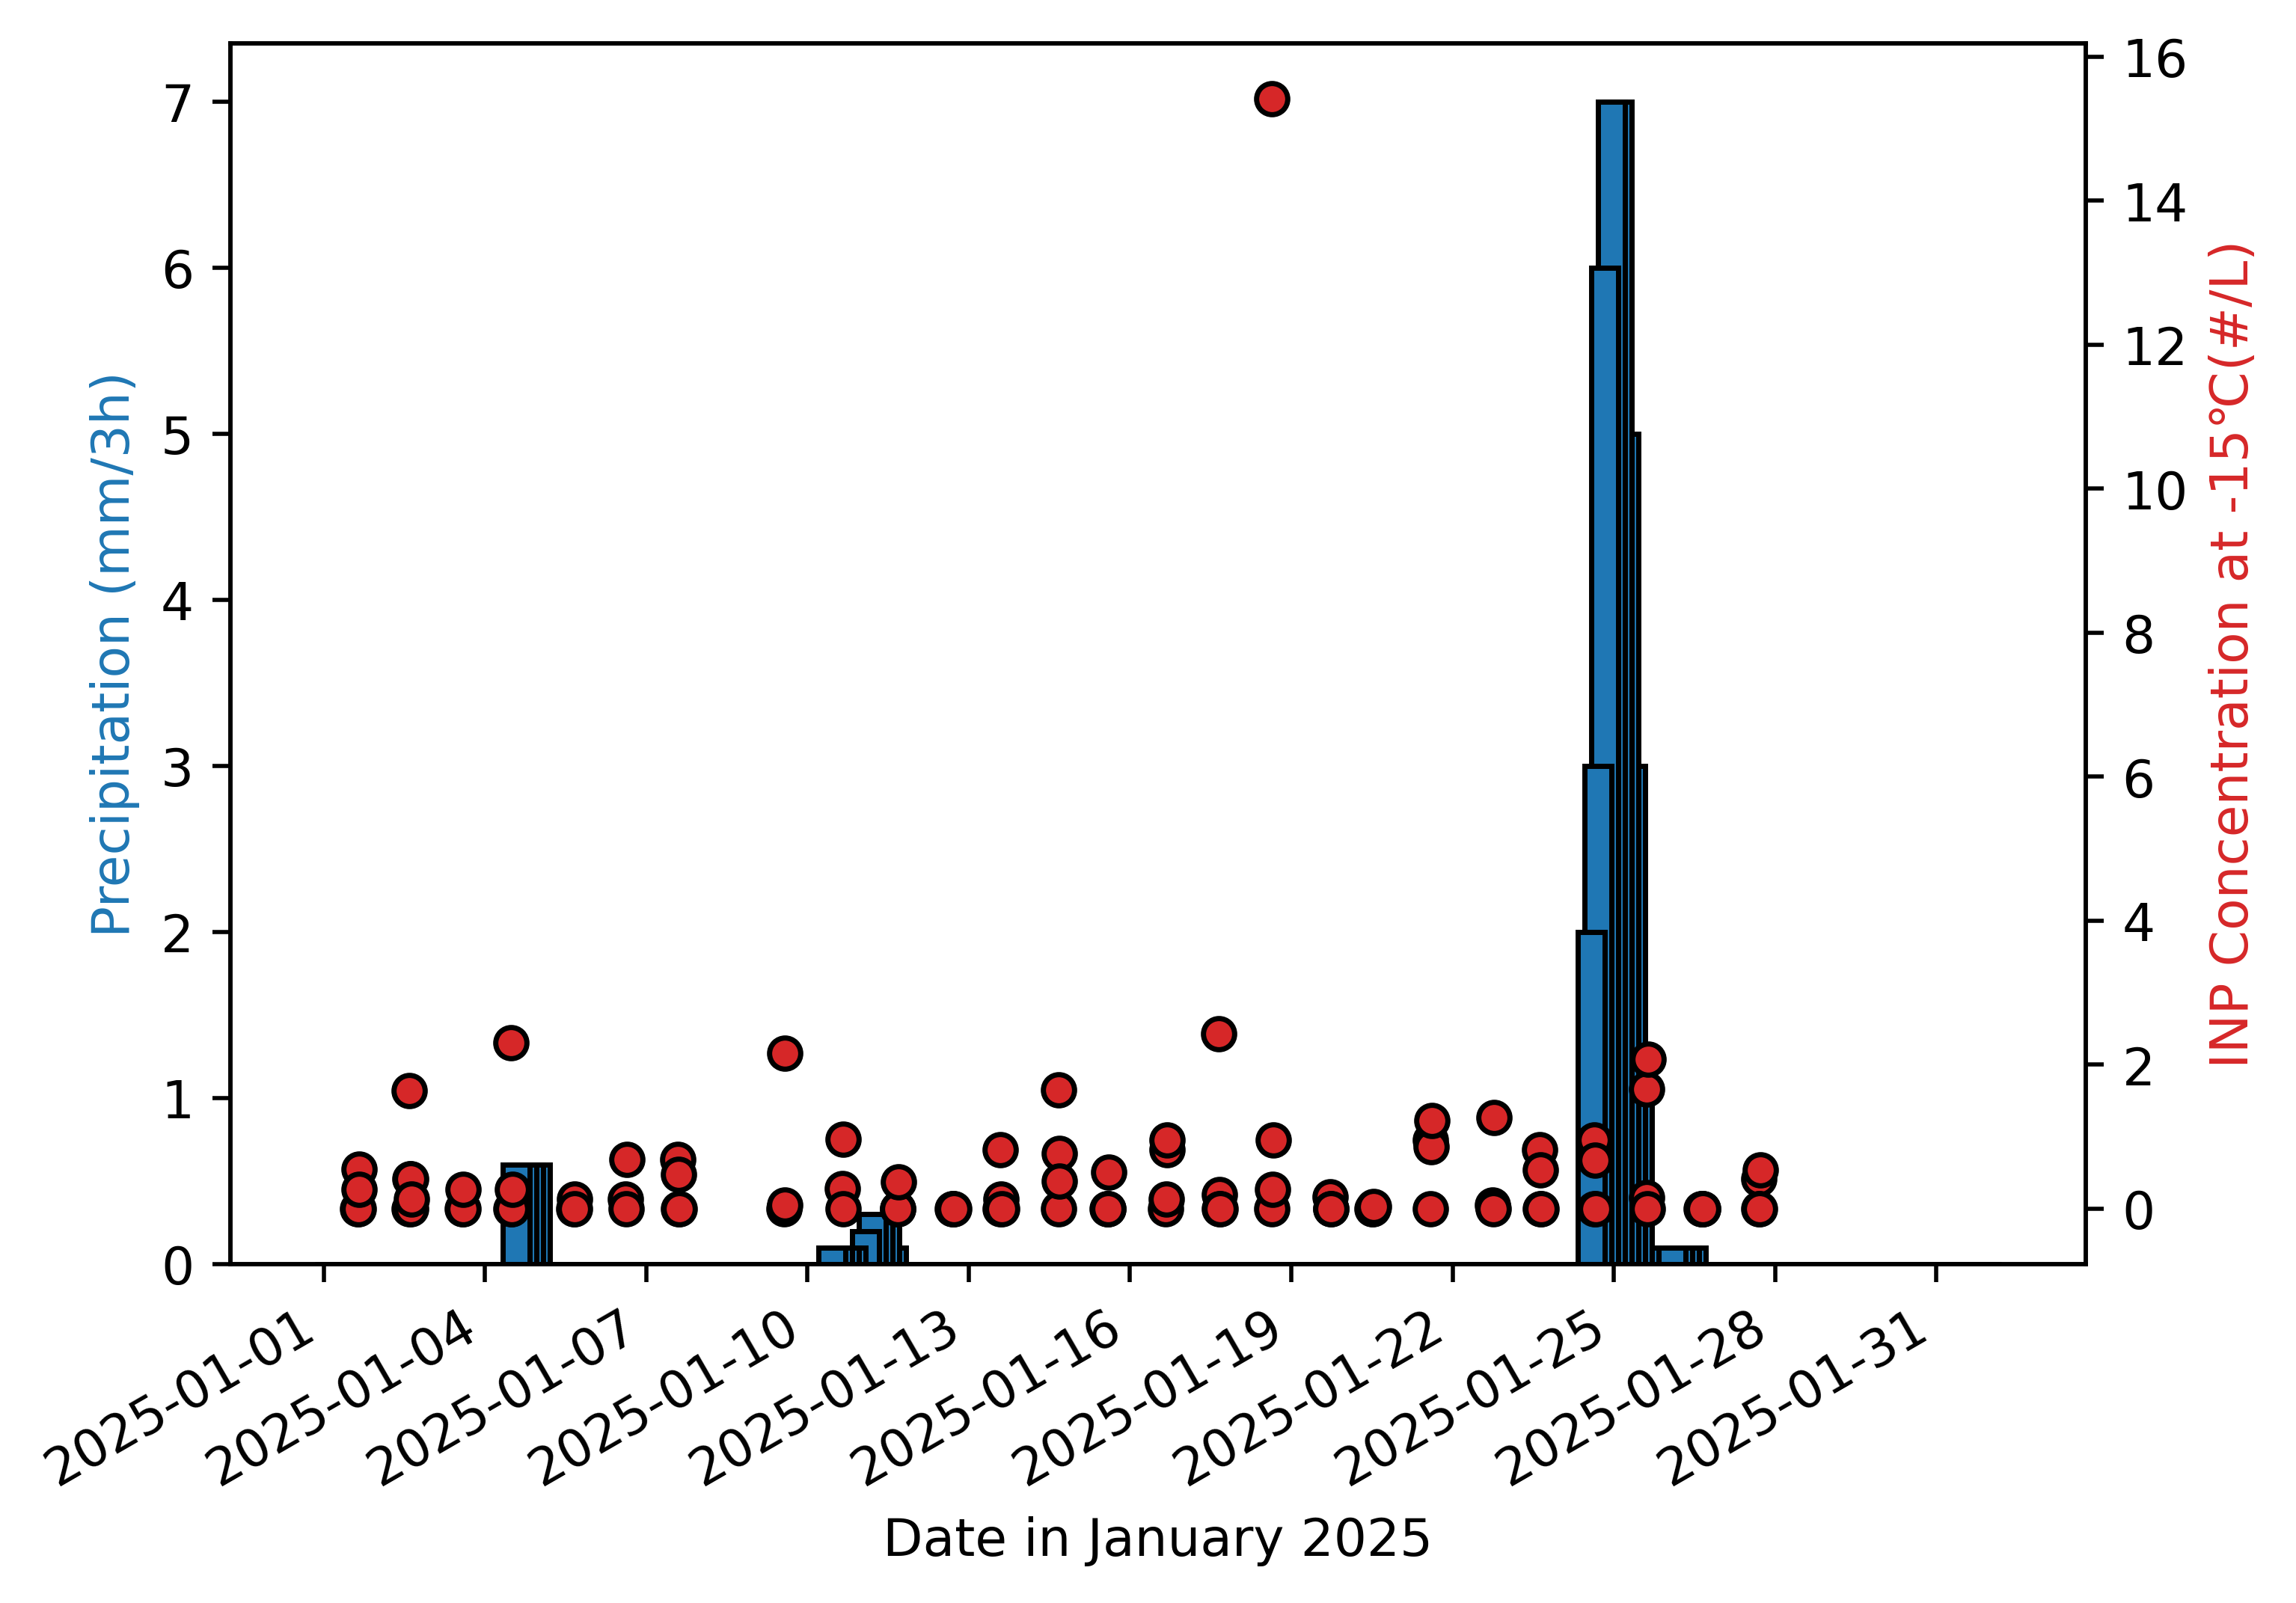

<Figure size 640x480 with 0 Axes>

In [33]:
## 可视化绘图: 线性坐标

fig = plt.figure(dpi=500)
ax1 = fig.add_subplot(111)

ax1.bar(x_prp, y_prp, color='tab:blue', edgecolor='k', width=0.5)
ax2 = ax1.twinx()
ax2.scatter(x_inp, y_inp, color='tab:red', edgecolor='k')
### x轴的设置
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=3))# 每隔3天设置一个主刻度
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gcf().autofmt_xdate()# 自动旋转日期标记
ax1.set_xlabel('Date in January 2025')###
### y轴的设置
ax1.set_ylabel('Precipitation (mm/3h)', color='tab:blue')
ax2.set_ylabel('INP Concentration at -15℃(#/L)', color='tab:red')###
### 保存图片
plt.show()
plt.savefig(r"D:\Coding\master0_2025\Lanzhou_cfdc\INP-15_jan_linear.png")###

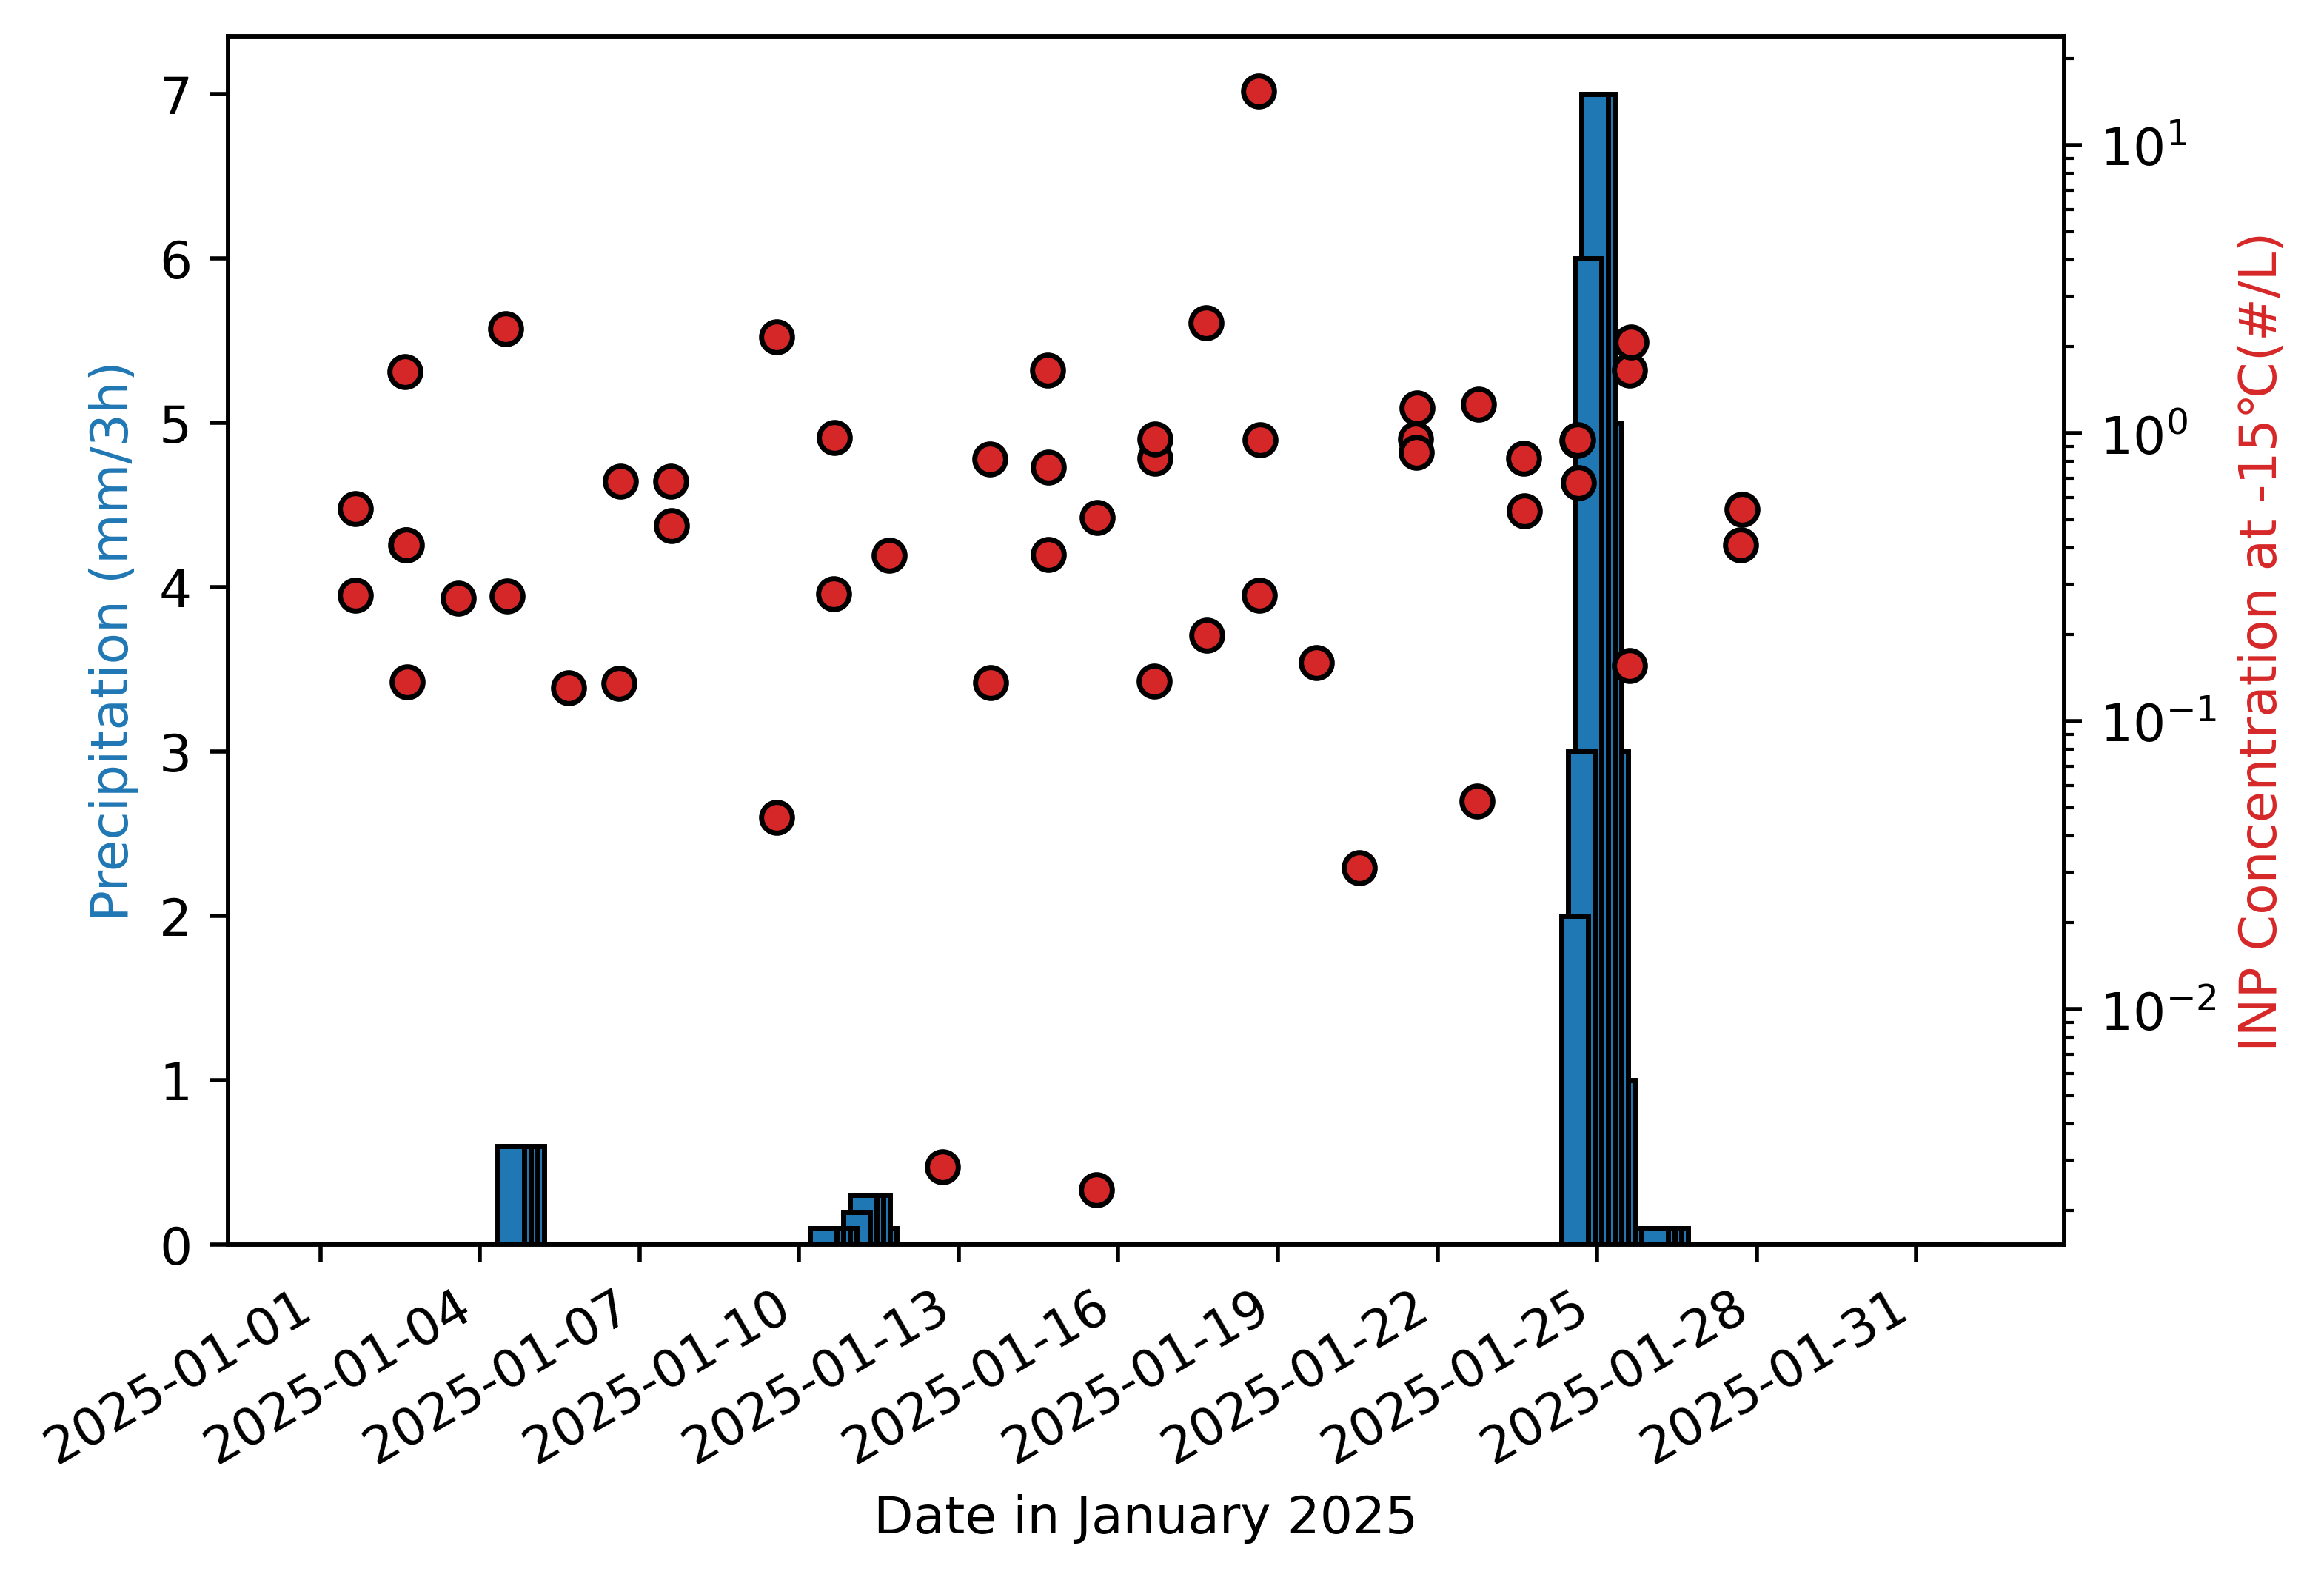

In [30]:
## 可视化绘图: log坐标系

fig = plt.figure(dpi=500)
ax1 = fig.add_subplot(111)

ax1.bar(x_prp, y_prp, color='tab:blue', edgecolor='k', width=0.5)
ax2 = ax1.twinx()
ax2.scatter(x_inp, y_inp, color='tab:red', edgecolor='k')
### x轴的设置
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=3))# 每隔3天设置一个主刻度
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gcf().autofmt_xdate()# 自动旋转日期标记
ax1.set_xlabel('Date in January 2025')###
### y轴的设置
ax1.set_ylabel('Precipitation (mm/3h)', color='tab:blue')
ax2.set_yscale('log')
ax2.set_ylabel('INP Concentration at -15℃(#/L)', color='tab:red')###
### 保存图片
plt.savefig(r"D:\Coding\master0_2025\Lanzhou_cfdc\INP-15_jan_log.png")###

## -20degC

In [38]:
## 可视化数据的提取与处理
### 处理INP数据
p = Path(r"D:\Coding\Data\Lanzhou_cfdc")
all_dates = []
all_INP = []

### 数据处理, 合并多天INP数据, 保存为列表格式
for file in p.glob("data_202501*.csv"):
    data = pd.read_csv(file).dropna(subset=['Lamina Average T [C]'])
    #### 确定日期
    base_date = pd.to_datetime(file.stem.split('_')[1][0:8])
    dt = base_date + pd.to_timedelta(data['Time'], unit='s')
    
    bac_toggle = data['Background INP avg [#/L] Toggle']
    sam_toggle = data['Sample INP avg [#/L] Toggle']
    #### -15degC下INP浓度提取, 修改此处温度值可选择不同温度下的INP浓度 ####
    N_inp_bac = data['Background INP avg [#/L]'][bac_toggle==True][data['Lamina T Set [C]']==-20.0].reindex(dt.index, fill_value=np.nan)
    N_inp_sam = data['Sample INP avg [#/L]'][sam_toggle==True][data['Lamina T Set [C]']==-20.0].reindex(dt.index, fill_value=np.nan)
    #### 计算净INP浓度
    N_inp_avg_net = compute_net(sam=N_inp_sam, bac=N_inp_bac)
    #### 保存为列表格式
    all_dates.append(dt[N_inp_avg_net.index])
    all_INP.append(N_inp_avg_net)
    #### 输出文件名以及该文件处理后的INP数据点数量
    print(f"Processed file: {file.name}, INP_net count: {len(N_inp_avg_net)}")

### 合并所有INP数据, 创建DataFrame(INP是其中一列)
all_dates = pd.concat(all_dates, ignore_index=True)# 在这之后, 索引变得不重要了
all_INP = pd.concat(all_INP, ignore_index=True)
df_inp = pd.DataFrame({'Date': all_dates,
                   'N_inp_net': all_INP})
### 处理降水数据
data_prp = pd.read_csv(r"D:\Coding\Data\Lanzhou_precipitation\rp5.ru\52983.01.02.2024.11.11.2025.1.0.0.en.utf8.00000000.csv"
    , skiprows=6
    , sep=";"
    , index_col=False
)
date = pd.to_datetime(data_prp['Local time in Lanzhou'], format='%d.%m.%Y %H:%M')
#### 选择2025年1月的数据, 修改此处时间可选择时间序列的起止时间 ####
data_prp_selected = data_prp[(date >= '2025-01-01') & (date < '2025-02-01')]
### 读取日期数据, 为绘图做准备
x_inp = df_inp['Date']
x_prp = pd.to_datetime(data_prp_selected['Local time in Lanzhou'], format='%d.%m.%Y %H:%M')
### 读取INP数据, 为绘图做准备
y_inp = df_inp['N_inp_net']
### 读取降水数据, 为绘图做准备
y_prp = data_prp_selected['RRR'].replace('No precipitation', 0).astype(float)

Processed file: data_20250101T101850.csv, INP_net count: 3
Processed file: data_20250102T085849.csv, INP_net count: 3
Processed file: data_20250103T091122.csv, INP_net count: 4
Processed file: data_20250104T071014.csv, INP_net count: 4
Processed file: data_20250105T112959.csv, INP_net count: 3
Processed file: data_20250106T093311.csv, INP_net count: 3
Sample and background have different number of measurement segments.
Before processing:
          value         tag
22159  1.293752  Background
22527  4.003858      Sample
22895  4.643284  Background
23263  6.321568      Sample
23631  5.282741  Background
23999  5.687833      Sample
24367  6.568261  Background
24735  8.277831      Sample
25103  7.398078  Background
After processing:
Background: 
 22159    1.293752
22895    4.643284
23631    5.282741
24367    6.568261
Name: value, dtype: float64
Sample: 
 22527    4.003858
23263    6.321568
23999    5.687833
24735    8.277831
Name: value, dtype: float64
Processed file: data_20250107T085804

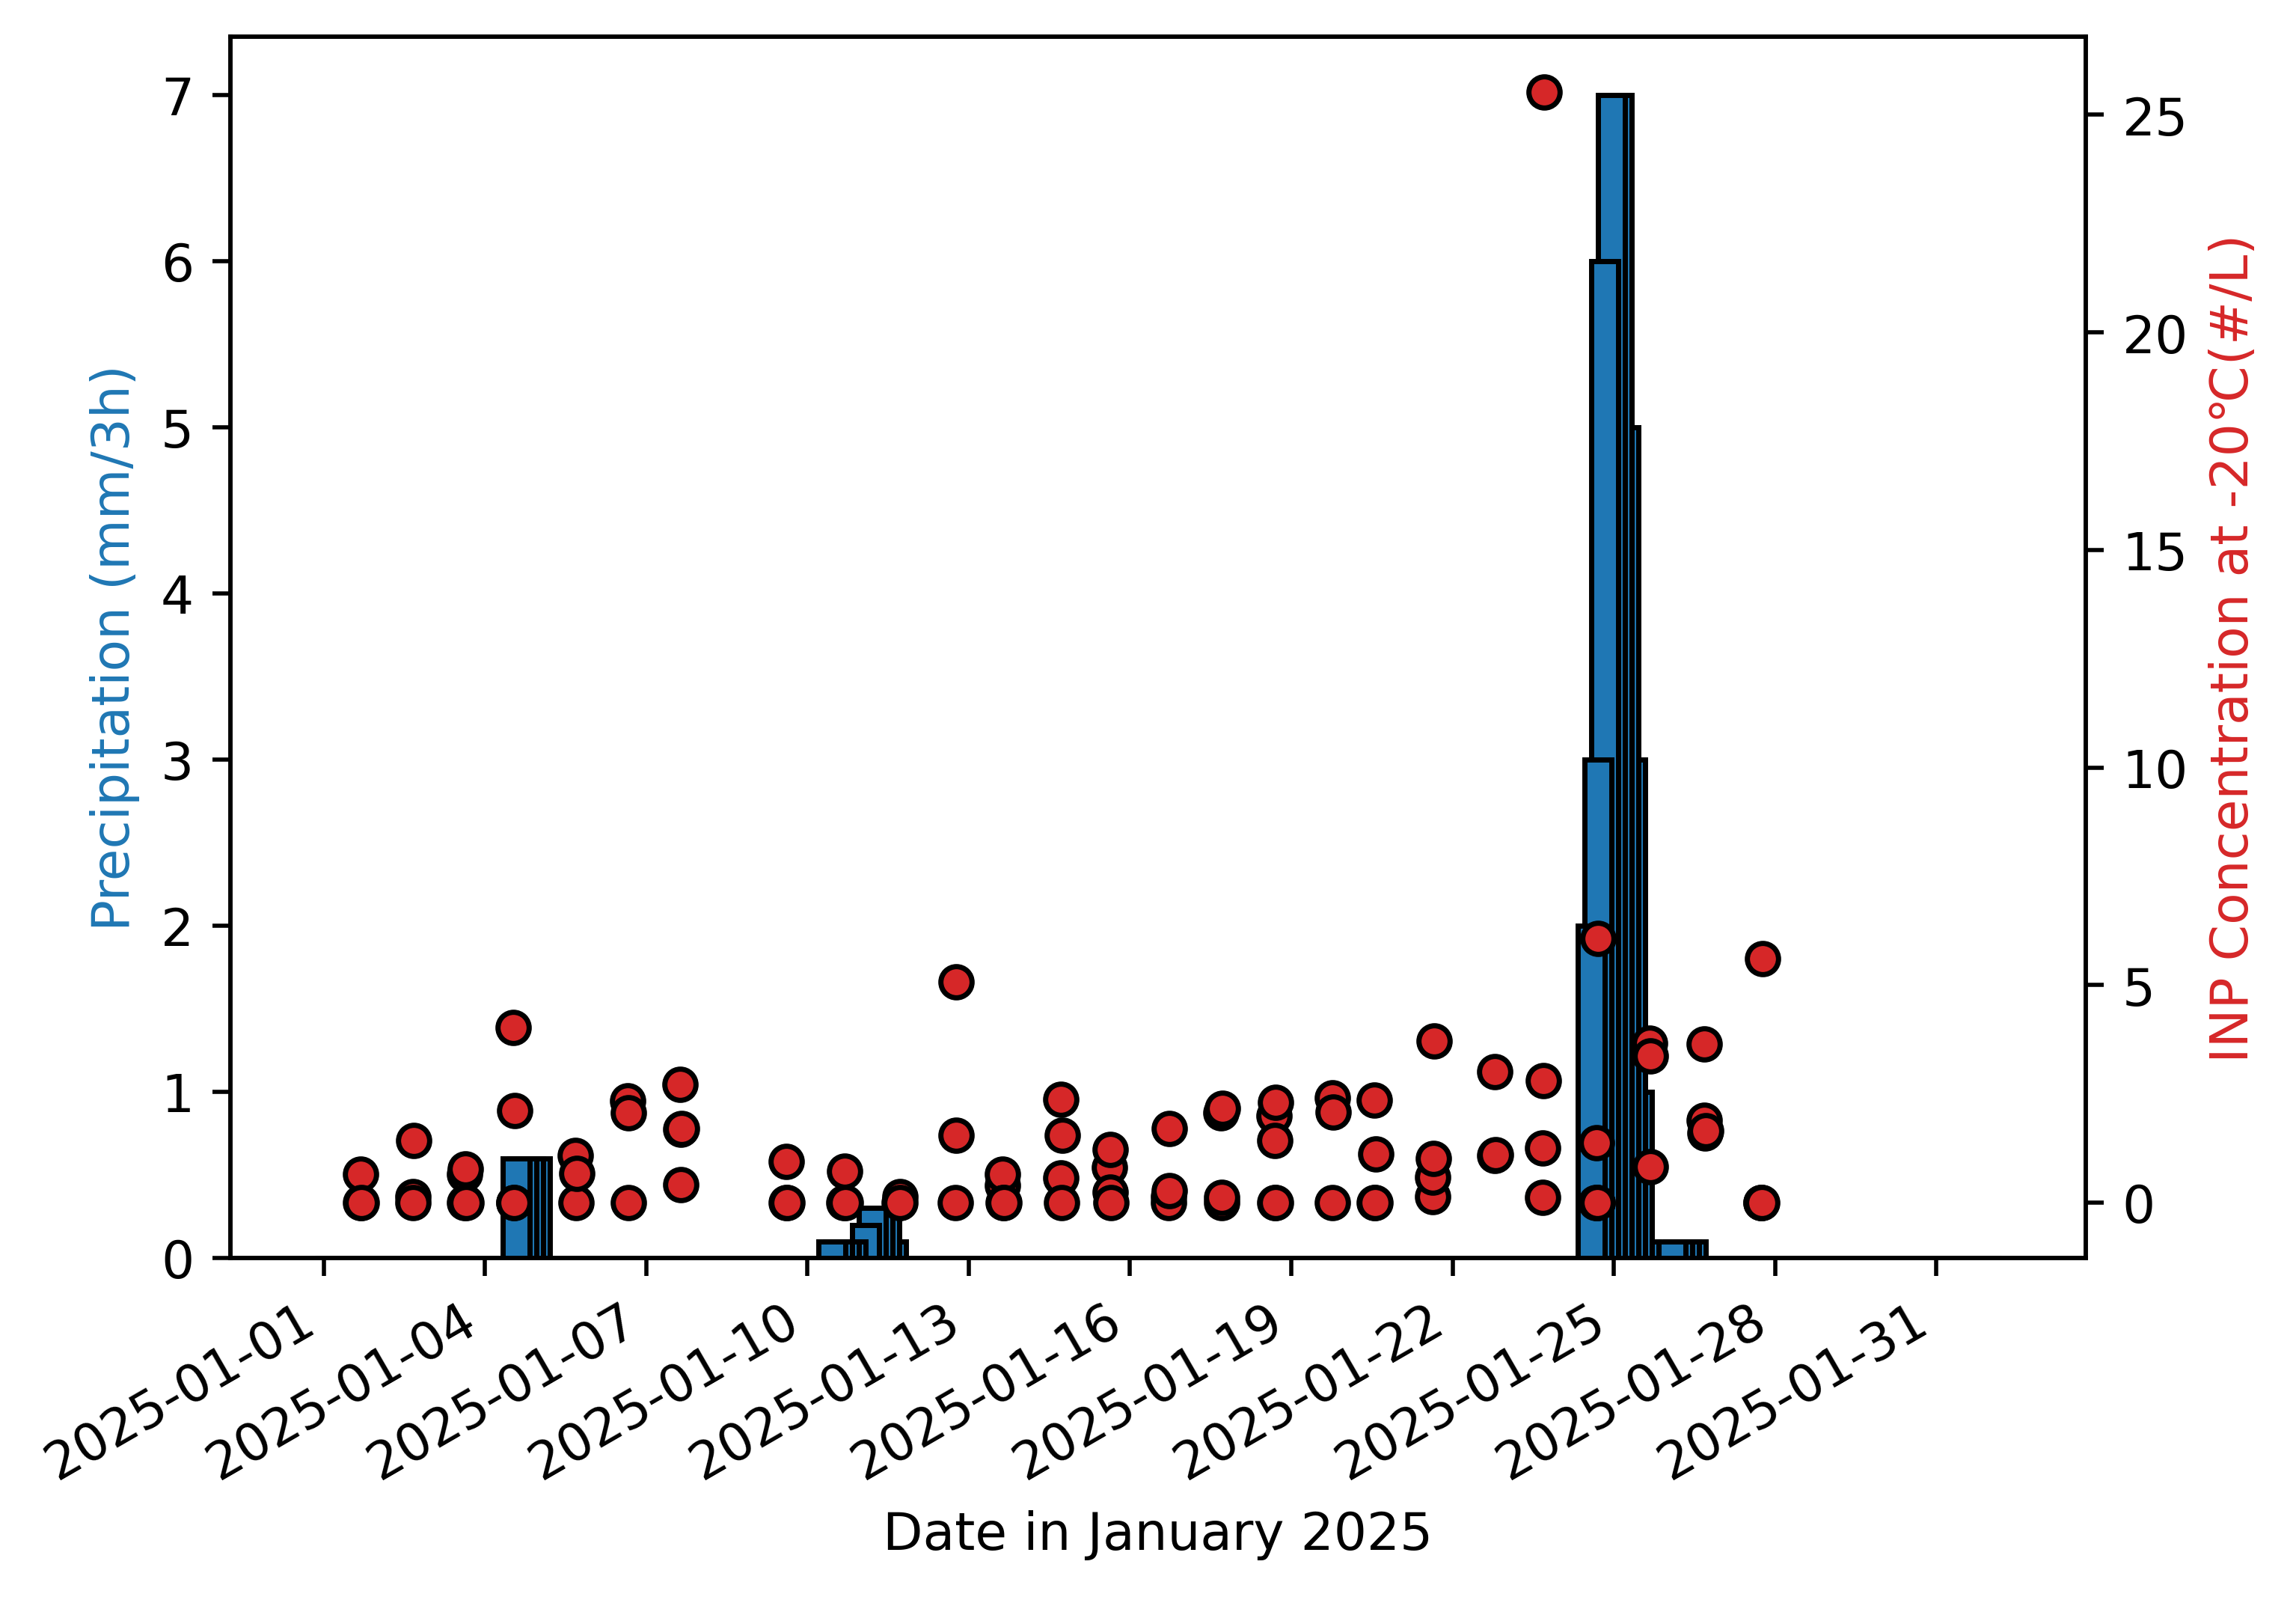

In [39]:
## 可视化绘图: 线性坐标

fig = plt.figure(dpi=500)
ax1 = fig.add_subplot(111)

ax1.bar(x_prp, y_prp, color='tab:blue', edgecolor='k', width=0.5)
ax2 = ax1.twinx()
ax2.scatter(x_inp, y_inp, color='tab:red', edgecolor='k')
### x轴的设置
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=3))# 每隔3天设置一个主刻度
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gcf().autofmt_xdate()# 自动旋转日期标记
ax1.set_xlabel('Date in January 2025')###
### y轴的设置
ax1.set_ylabel('Precipitation (mm/3h)', color='tab:blue')
ax2.set_ylabel('INP Concentration at -20℃(#/L)', color='tab:red')###
### 保存图片
plt.savefig(r"D:\Coding\master0_2025\Lanzhou_cfdc\INP-20_jan_linear.png")###

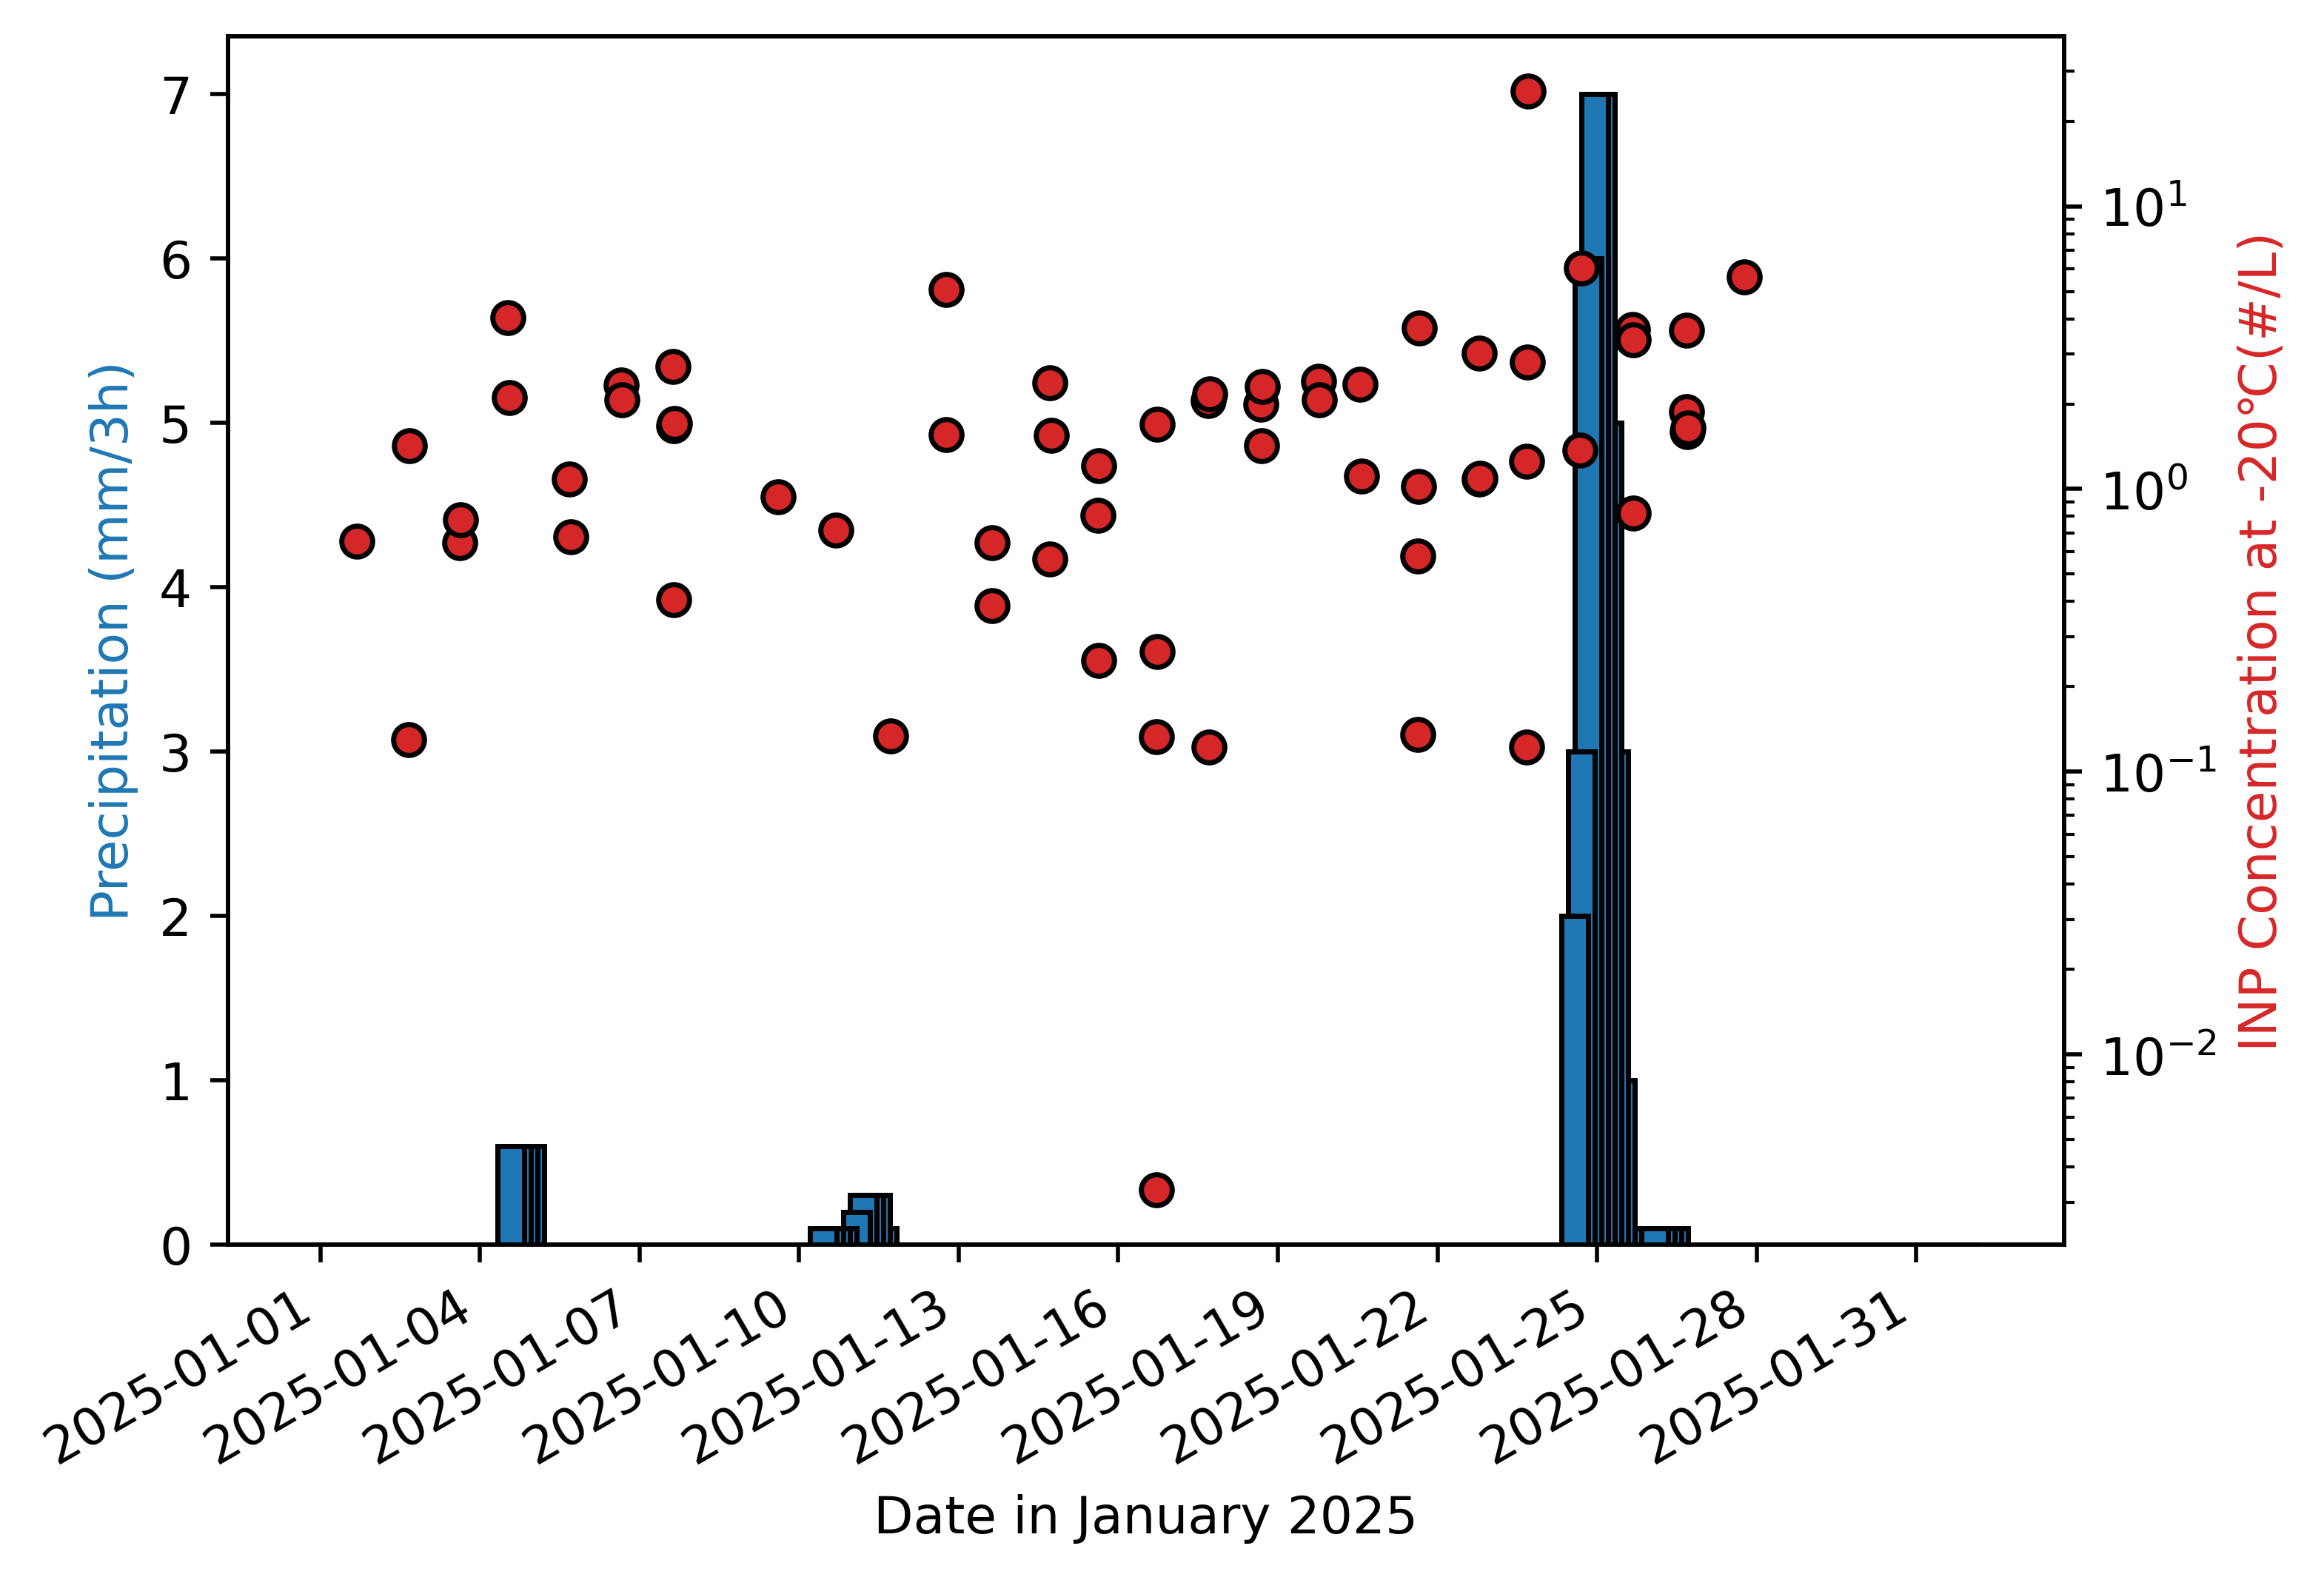

In [40]:
## 可视化绘图: log坐标系

fig = plt.figure(dpi=500)
ax1 = fig.add_subplot(111)

ax1.bar(x_prp, y_prp, color='tab:blue', edgecolor='k', width=0.5)
ax2 = ax1.twinx()
ax2.scatter(x_inp, y_inp, color='tab:red', edgecolor='k')
### x轴的设置
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=3))# 每隔3天设置一个主刻度
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gcf().autofmt_xdate()# 自动旋转日期标记
ax1.set_xlabel('Date in January 2025')###
### y轴的设置
ax1.set_ylabel('Precipitation (mm/3h)', color='tab:blue')
ax2.set_yscale('log')
ax2.set_ylabel('INP Concentration at -20℃(#/L)', color='tab:red')###
### 保存图片
plt.savefig(r"D:\Coding\master0_2025\Lanzhou_cfdc\INP-20_jan_log.png")###

## -25degC

In [41]:
## 可视化数据的提取与处理
### 处理INP数据
p = Path(r"D:\Coding\Data\Lanzhou_cfdc")
all_dates = []
all_INP = []

### 数据处理, 合并多天INP数据, 保存为列表格式
for file in p.glob("data_202501*.csv"):
    data = pd.read_csv(file).dropna(subset=['Lamina Average T [C]'])
    #### 确定日期
    base_date = pd.to_datetime(file.stem.split('_')[1][0:8])
    dt = base_date + pd.to_timedelta(data['Time'], unit='s')
    
    bac_toggle = data['Background INP avg [#/L] Toggle']
    sam_toggle = data['Sample INP avg [#/L] Toggle']
    #### -15degC下INP浓度提取, 修改此处温度值可选择不同温度下的INP浓度 ####
    N_inp_bac = data['Background INP avg [#/L]'][bac_toggle==True][data['Lamina T Set [C]']==-25.0].reindex(dt.index, fill_value=np.nan)
    N_inp_sam = data['Sample INP avg [#/L]'][sam_toggle==True][data['Lamina T Set [C]']==-25.0].reindex(dt.index, fill_value=np.nan)
    #### 计算净INP浓度
    N_inp_avg_net = compute_net(sam=N_inp_sam, bac=N_inp_bac)
    #### 保存为列表格式
    all_dates.append(dt[N_inp_avg_net.index])
    all_INP.append(N_inp_avg_net)
    #### 输出文件名以及该文件处理后的INP数据点数量
    print(f"Processed file: {file.name}, INP_net count: {len(N_inp_avg_net)}")

### 合并所有INP数据, 创建DataFrame(INP是其中一列)
all_dates = pd.concat(all_dates, ignore_index=True)# 在这之后, 索引变得不重要了
all_INP = pd.concat(all_INP, ignore_index=True)
df_inp = pd.DataFrame({'Date': all_dates,
                   'N_inp_net': all_INP})
### 处理降水数据
data_prp = pd.read_csv(r"D:\Coding\Data\Lanzhou_precipitation\rp5.ru\52983.01.02.2024.11.11.2025.1.0.0.en.utf8.00000000.csv"
    , skiprows=6
    , sep=";"
    , index_col=False
)
date = pd.to_datetime(data_prp['Local time in Lanzhou'], format='%d.%m.%Y %H:%M')
#### 选择2025年1月的数据, 修改此处时间可选择时间序列的起止时间 ####
data_prp_selected = data_prp[(date >= '2025-01-01') & (date < '2025-02-01')]
### 读取日期数据, 为绘图做准备
x_inp = df_inp['Date']
x_prp = pd.to_datetime(data_prp_selected['Local time in Lanzhou'], format='%d.%m.%Y %H:%M')
### 读取INP数据, 为绘图做准备
y_inp = df_inp['N_inp_net']
### 读取降水数据, 为绘图做准备
y_prp = data_prp_selected['RRR'].replace('No precipitation', 0).astype(float)

Processed file: data_20250101T101850.csv, INP_net count: 3
Processed file: data_20250102T085849.csv, INP_net count: 4
Processed file: data_20250103T091122.csv, INP_net count: 5
Sample and background have different number of measurement segments.
Before processing:
           value         tag
23393   7.064138  Background
23885  12.435583  Background
24253  11.093050      Sample
24621   9.012597  Background
24989  10.830497      Sample
25357   9.561696  Background
25725  13.492025      Sample
26093  13.944122  Background
26461  15.990964      Sample
After processing:
Background: 
 23885    12.435583
24621     9.012597
25357     9.561696
26093    13.944122
Name: value, dtype: float64
Sample: 
 24253    11.093050
24989    10.830497
25725    13.492025
26461    15.990964
Name: value, dtype: float64
Processed file: data_20250104T071014.csv, INP_net count: 4
Processed file: data_20250105T112959.csv, INP_net count: 3
Sample and background have different number of measurement segments.
Before p

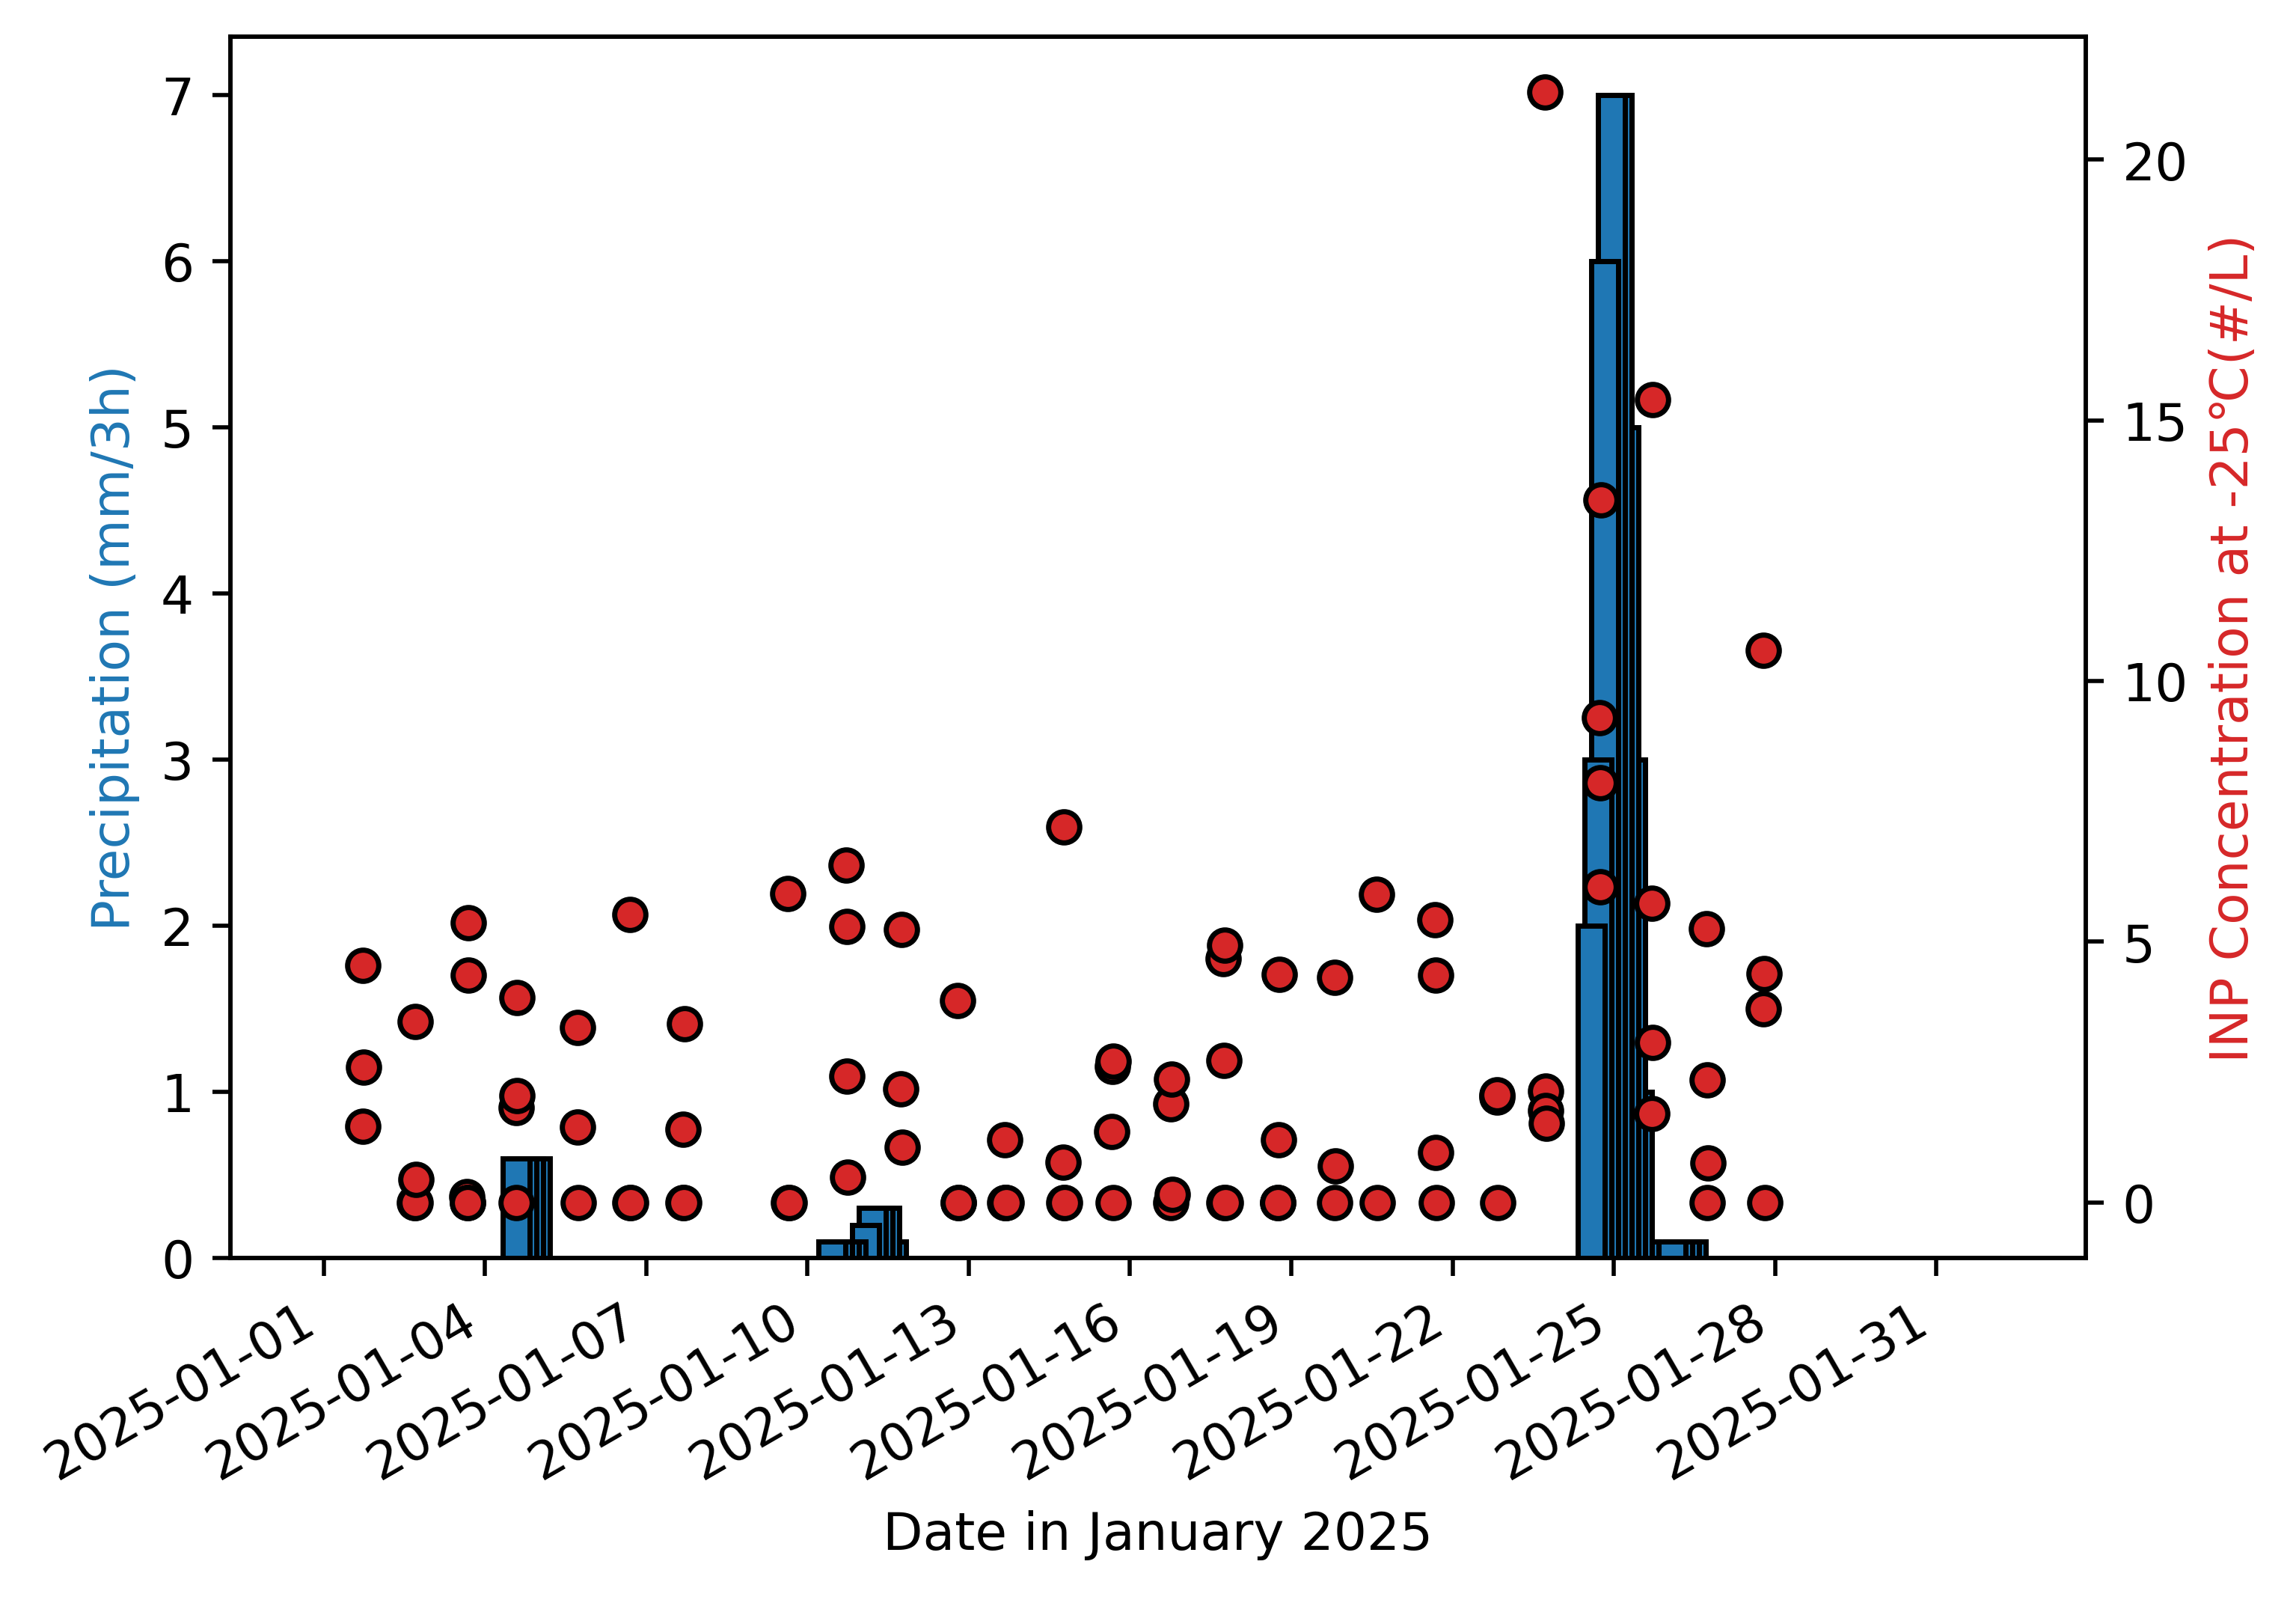

In [42]:
## 可视化绘图: 线性坐标

fig = plt.figure(dpi=500)
ax1 = fig.add_subplot(111)

ax1.bar(x_prp, y_prp, color='tab:blue', edgecolor='k', width=0.5)
ax2 = ax1.twinx()
ax2.scatter(x_inp, y_inp, color='tab:red', edgecolor='k')
### x轴的设置
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=3))# 每隔3天设置一个主刻度
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gcf().autofmt_xdate()# 自动旋转日期标记
ax1.set_xlabel('Date in January 2025')###
### y轴的设置
ax1.set_ylabel('Precipitation (mm/3h)', color='tab:blue')
ax2.set_ylabel('INP Concentration at -25℃(#/L)', color='tab:red')###
### 保存图片
plt.savefig(r"D:\Coding\master0_2025\Lanzhou_cfdc\INP-25_jan_linear.png")###

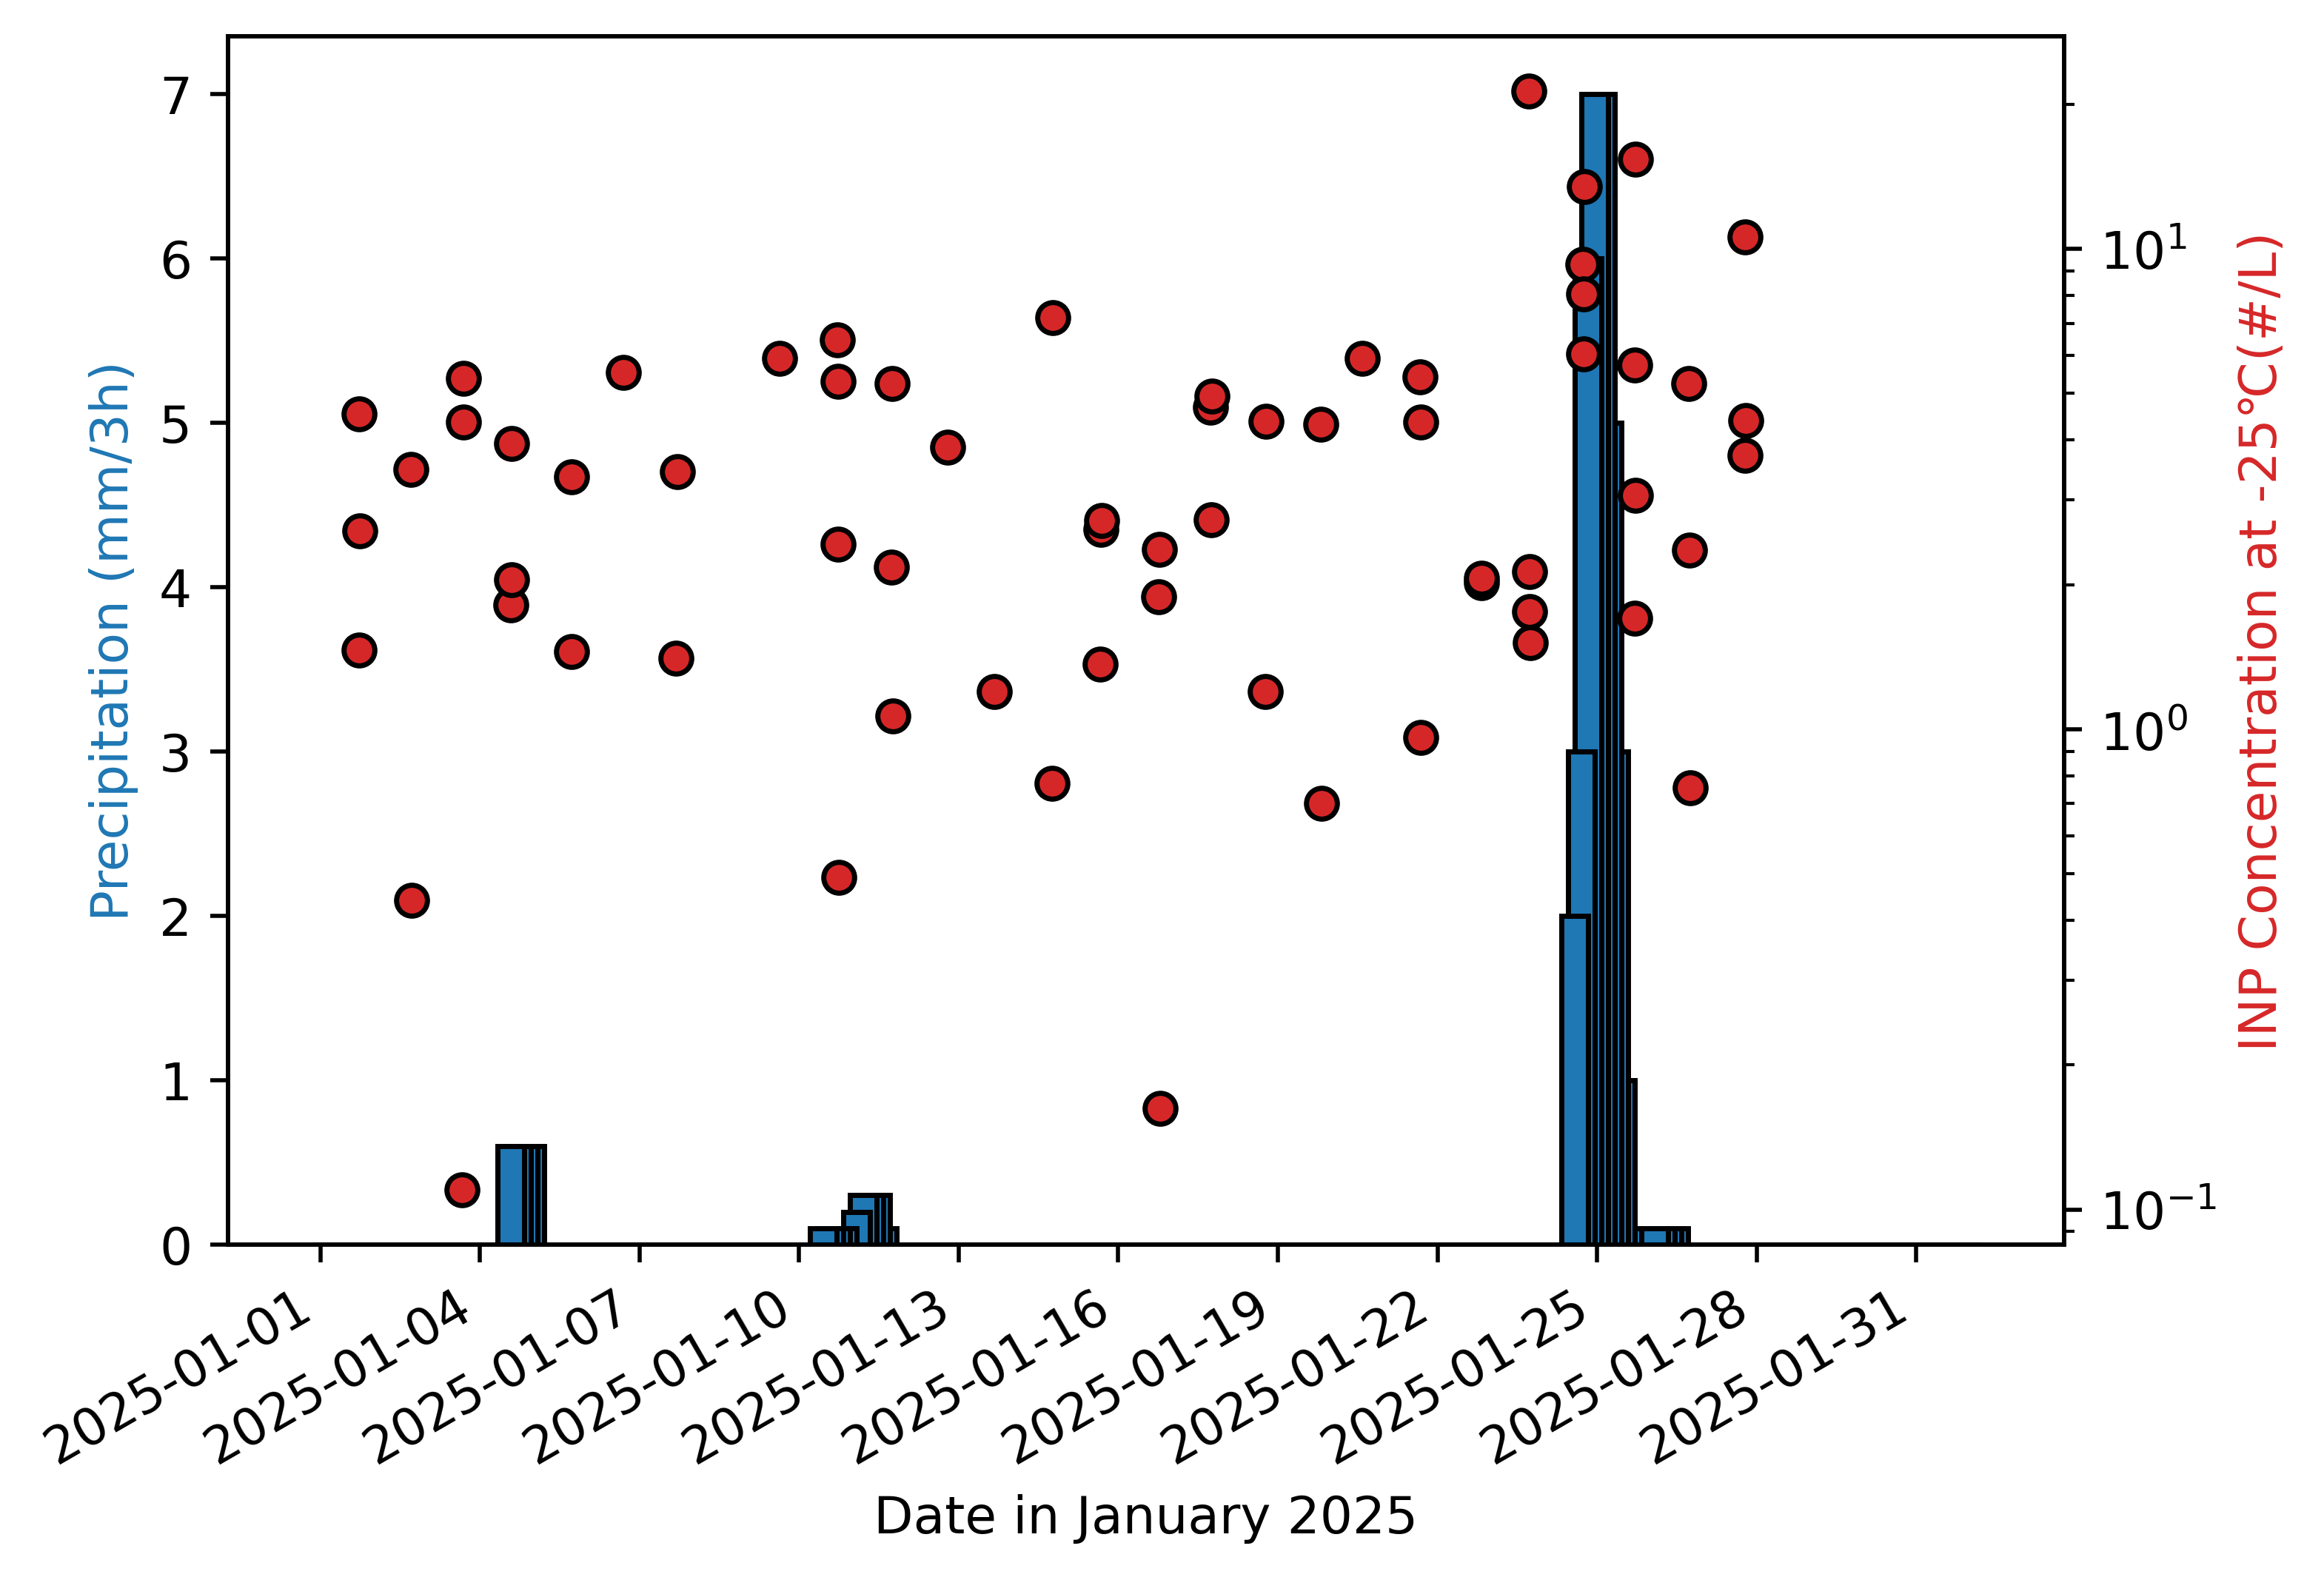

In [43]:
## 可视化绘图: log坐标系

fig = plt.figure(dpi=500)
ax1 = fig.add_subplot(111)

ax1.bar(x_prp, y_prp, color='tab:blue', edgecolor='k', width=0.5)
ax2 = ax1.twinx()
ax2.scatter(x_inp, y_inp, color='tab:red', edgecolor='k')
### x轴的设置
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=3))# 每隔3天设置一个主刻度
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gcf().autofmt_xdate()# 自动旋转日期标记
ax1.set_xlabel('Date in January 2025')###
### y轴的设置
ax1.set_ylabel('Precipitation (mm/3h)', color='tab:blue')
ax2.set_yscale('log')
ax2.set_ylabel('INP Concentration at -25℃(#/L)', color='tab:red')###
### 保存图片
plt.savefig(r"D:\Coding\master0_2025\Lanzhou_cfdc\INP-25_jan_log.png")###

## -30degC

In [44]:
## 可视化数据的提取与处理
### 处理INP数据
p = Path(r"D:\Coding\Data\Lanzhou_cfdc")
all_dates = []
all_INP = []

### 数据处理, 合并多天INP数据, 保存为列表格式
for file in p.glob("data_202501*.csv"):
    data = pd.read_csv(file).dropna(subset=['Lamina Average T [C]'])
    #### 确定日期
    base_date = pd.to_datetime(file.stem.split('_')[1][0:8])
    dt = base_date + pd.to_timedelta(data['Time'], unit='s')
    
    bac_toggle = data['Background INP avg [#/L] Toggle']
    sam_toggle = data['Sample INP avg [#/L] Toggle']
    #### -15degC下INP浓度提取, 修改此处温度值可选择不同温度下的INP浓度 ####
    N_inp_bac = data['Background INP avg [#/L]'][bac_toggle==True][data['Lamina T Set [C]']==-30.0].reindex(dt.index, fill_value=np.nan)
    N_inp_sam = data['Sample INP avg [#/L]'][sam_toggle==True][data['Lamina T Set [C]']==-30.0].reindex(dt.index, fill_value=np.nan)
    #### 计算净INP浓度
    N_inp_avg_net = compute_net(sam=N_inp_sam, bac=N_inp_bac)
    #### 保存为列表格式
    all_dates.append(dt[N_inp_avg_net.index])
    all_INP.append(N_inp_avg_net)
    #### 输出文件名以及该文件处理后的INP数据点数量
    print(f"Processed file: {file.name}, INP_net count: {len(N_inp_avg_net)}")

### 合并所有INP数据, 创建DataFrame(INP是其中一列)
all_dates = pd.concat(all_dates, ignore_index=True)# 在这之后, 索引变得不重要了
all_INP = pd.concat(all_INP, ignore_index=True)
df_inp = pd.DataFrame({'Date': all_dates,
                   'N_inp_net': all_INP})
### 处理降水数据
data_prp = pd.read_csv(r"D:\Coding\Data\Lanzhou_precipitation\rp5.ru\52983.01.02.2024.11.11.2025.1.0.0.en.utf8.00000000.csv"
    , skiprows=6
    , sep=";"
    , index_col=False
)
date = pd.to_datetime(data_prp['Local time in Lanzhou'], format='%d.%m.%Y %H:%M')
#### 选择2025年1月的数据, 修改此处时间可选择时间序列的起止时间 ####
data_prp_selected = data_prp[(date >= '2025-01-01') & (date < '2025-02-01')]
### 读取日期数据, 为绘图做准备
x_inp = df_inp['Date']
x_prp = pd.to_datetime(data_prp_selected['Local time in Lanzhou'], format='%d.%m.%Y %H:%M')
### 读取INP数据, 为绘图做准备
y_inp = df_inp['N_inp_net']
### 读取降水数据, 为绘图做准备
y_prp = data_prp_selected['RRR'].replace('No precipitation', 0).astype(float)

Processed file: data_20250101T101850.csv, INP_net count: 3
Processed file: data_20250102T085849.csv, INP_net count: 4
Processed file: data_20250103T091122.csv, INP_net count: 3
Processed file: data_20250104T071014.csv, INP_net count: 4
Processed file: data_20250105T112959.csv, INP_net count: 4
Processed file: data_20250106T093311.csv, INP_net count: 3
Processed file: data_20250107T085804.csv, INP_net count: 4
Processed file: data_20250108T090416.csv, INP_net count: 28
Processed file: data_20250109T092151.csv, INP_net count: 3
Processed file: data_20250110T103738.csv, INP_net count: 3
Processed file: data_20250111T114104.csv, INP_net count: 3
Processed file: data_20250112T120459.csv, INP_net count: 3
Processed file: data_20250113T093107.csv, INP_net count: 5
Processed file: data_20250114T103226.csv, INP_net count: 4
Processed file: data_20250115T100952.csv, INP_net count: 5
Processed file: data_20250116T111317.csv, INP_net count: 7
Processed file: data_20250117T111902.csv, INP_net count

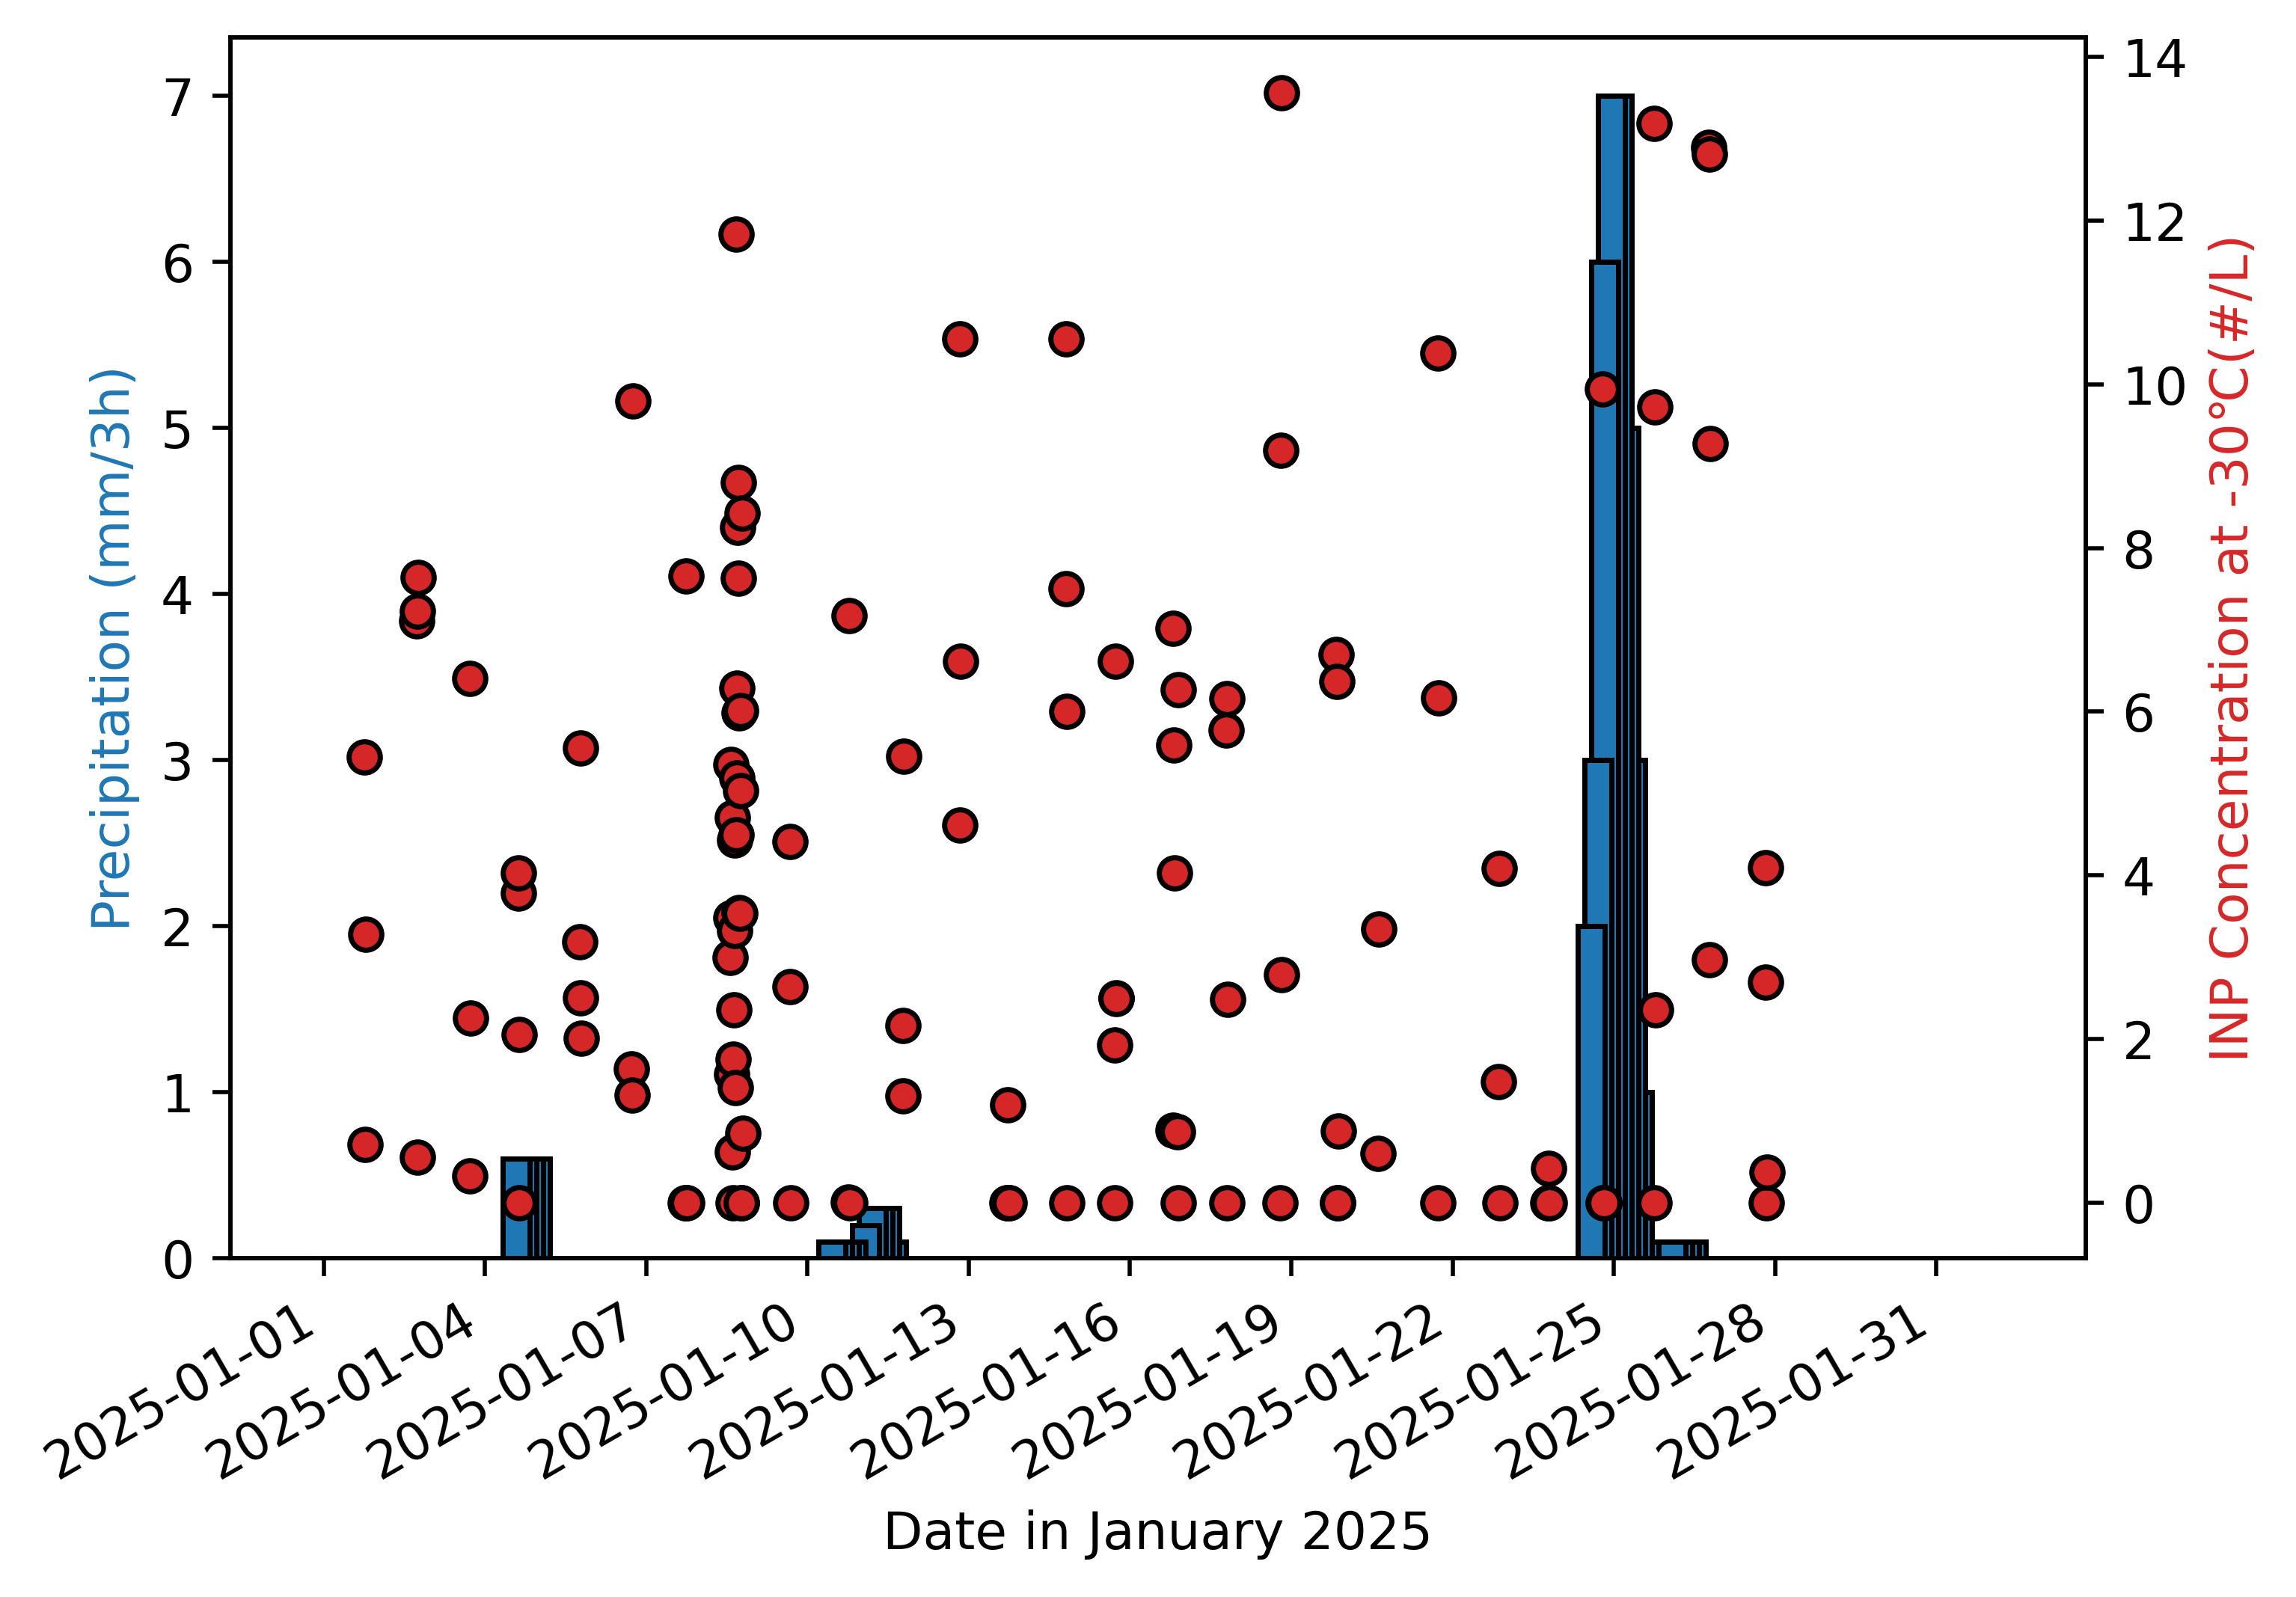

In [45]:
## 可视化绘图: 线性坐标

fig = plt.figure(dpi=500)
ax1 = fig.add_subplot(111)

ax1.bar(x_prp, y_prp, color='tab:blue', edgecolor='k', width=0.5)
ax2 = ax1.twinx()
ax2.scatter(x_inp, y_inp, color='tab:red', edgecolor='k')
### x轴的设置
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=3))# 每隔3天设置一个主刻度
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gcf().autofmt_xdate()# 自动旋转日期标记
ax1.set_xlabel('Date in January 2025')###
### y轴的设置
ax1.set_ylabel('Precipitation (mm/3h)', color='tab:blue')
ax2.set_ylabel('INP Concentration at -30℃(#/L)', color='tab:red')###
### 保存图片
plt.savefig(r"D:\Coding\master0_2025\Lanzhou_cfdc\INP-30_jan_linear.png")###

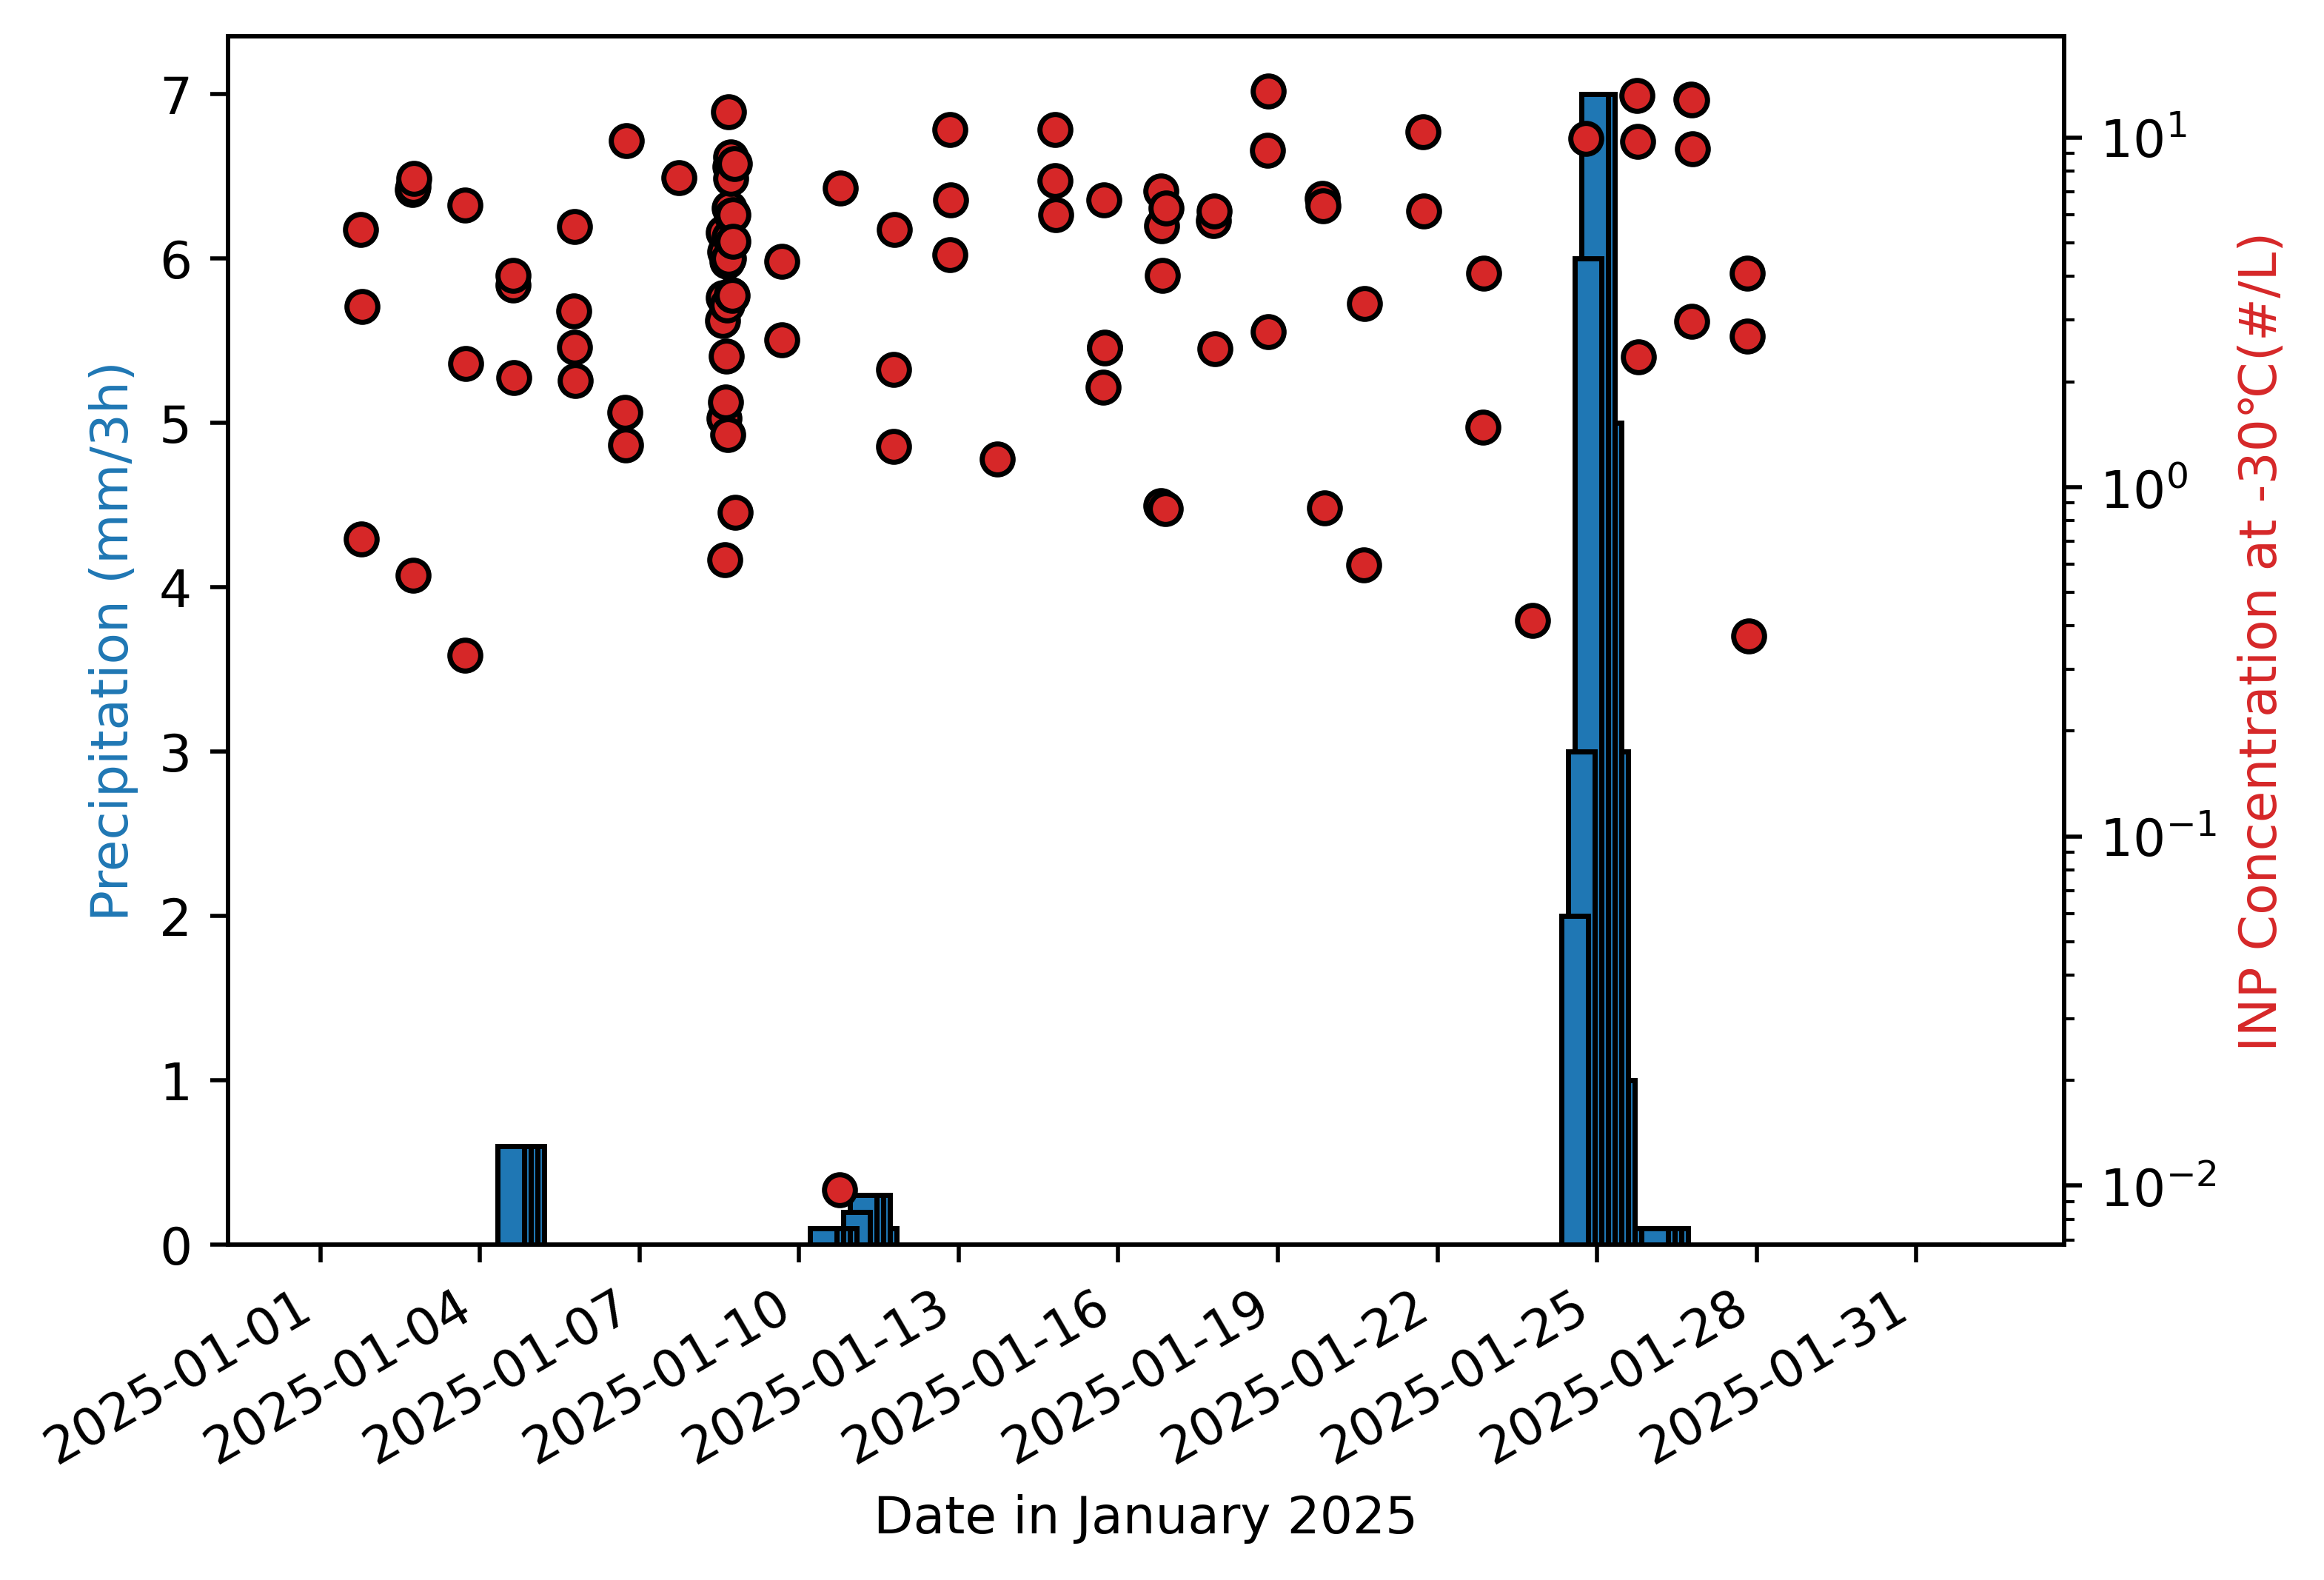

In [46]:
## 可视化绘图: log坐标系

fig = plt.figure(dpi=500)
ax1 = fig.add_subplot(111)

ax1.bar(x_prp, y_prp, color='tab:blue', edgecolor='k', width=0.5)
ax2 = ax1.twinx()
ax2.scatter(x_inp, y_inp, color='tab:red', edgecolor='k')
### x轴的设置
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=3))# 每隔3天设置一个主刻度
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gcf().autofmt_xdate()# 自动旋转日期标记
ax1.set_xlabel('Date in January 2025')###
### y轴的设置
ax1.set_ylabel('Precipitation (mm/3h)', color='tab:blue')
ax2.set_yscale('log')
ax2.set_ylabel('INP Concentration at -30℃(#/L)', color='tab:red')###
### 保存图片
plt.savefig(r"D:\Coding\master0_2025\Lanzhou_cfdc\INP-30_jan_log.png")###

In [ ]:
### 弃案: 由于降低了原始数据的分辨率, 故弃用此函数

def compute_avg(s, round_index=True):
    """
    从 Series 中提取每段非 NaN 区间的尾值，并计算：
    - 尾值的平均
    - 索引平均（可选四舍五入）
    
    参数:
        s: pd.Series
        round_index : bool, 默认为 True, 是否对 index 均值四舍五入
    
    返回:
        pd.Series, 索引 = 平均 index, 值 = 平均尾值
        如果没有任何尾值，返回一个空 Series
    """

    ### 保证输入是 Series
    if not isinstance(s, pd.Series):
        raise TypeError("Input must be a pandas Series.")

    ### 1. 提取每段非 NaN 区间的尾值
    mask = s.notna() & s.shift(-1).isna()
    s_last = s[mask]

    ### 2. 如果没有尾值，返回空 Series
    if len(s_last) == 0:
        return pd.Series(np.nan, index=[np.mean(s.index)])

    ###3. 计算值和索引的均值
    value_mean = s_last.mean()
    index_mean = np.mean(s_last.index)

    if round_index:
        index_mean = int(round(index_mean))

    ### 4. 返回带“平均索引”的 Series
    return pd.Series(value_mean, index=[index_mean])


def compute_net(sam, bac):
    """
    输入两个时间序列, 先计算两者的均值, 再计算差值(采样值-背景值)
    
    参数:
        sam: pd.Series, 采样值时间序列
        bac: pd.Series, 背景值时间序列
    返回:
        pd.Series, 差值时间序列
        若差值小于0, 则返回0
    """
    sam_avg = compute_avg(sam)
    bac_avg = compute_avg(bac)

    ### 最终 index = 这两个均值索引的平均
    final_index = int(round((sam_avg.index[0] + bac_avg.index[0]) / 2))

    net = float(sam_avg.values[0] - bac_avg.values[0])

    return pd.Series(max(net, 0.0), index=[final_index])